JAX Backend: [CpuDevice(id=0)]

Running q-Racah 6j-Symbol Scan (Clean Version)
Configuration: All spins j=1.0
Scanning 2000 theta points...
Computation Complete.
Saved plot to q_racah_6j_scan.png
Saved data to q_racah_data.txt


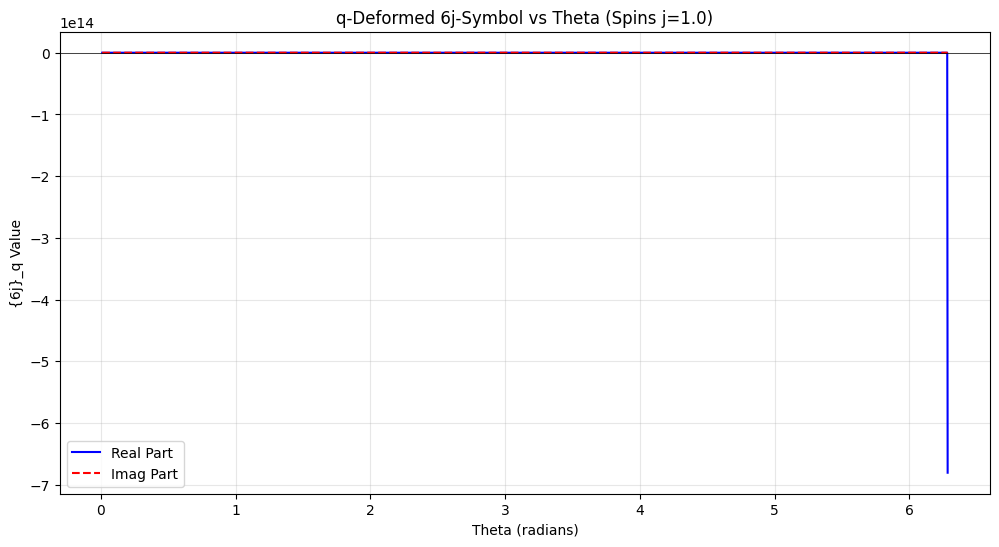

In [2]:
"""
q-Racah 6j-Symbol Calculator (JAX/GPU) - CLEAN VERSION

Purpose:
Computes the q-deformed 6j-symbols for SU_q(2), which encode the
topological theta-term in the 4D YM lattice model.

Features:
- JAX-accelerated for massive parallelization over theta.
- Robust handling of static arguments for JIT compilation.
- Automatic GPU detection.

Usage:
1. Upload to Google Colab.
2. Run the cell.
3. Output plot 'q_racah_6j_scan.png' will be saved.
"""

import sys
import subprocess

# 1. Environment Setup & Dependency Check
# (Standard Colab has jax, numpy, matplotlib. If missing, we install.)
try:
    import jax
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    import numpy as np
except ImportError as e:
    print(f"Missing dependency: {e}. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jax[cuda]", "matplotlib", "numpy"])
    import jax
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    import numpy as np

from functools import partial

# 2. Hardware Check
print(f"JAX Backend: {jax.devices()}")

# Enable 64-bit precision for factorials/large numbers
jax.config.update("jax_enable_x64", True)

# -----------------------------------------------------------------------------
# Math Functions
# -----------------------------------------------------------------------------

@jax.jit
def q_number(n, theta):
    """
    Computes [n]_q = sin(n*theta)/sin(theta).
    Handles the limit theta->0 safely.
    """
    denom = jnp.sin(theta)
    # Avoid division by zero
    safe_denom = jnp.where(jnp.abs(denom) < 1e-12, 1.0, denom)
    val = jnp.sin(n * theta) / safe_denom

    # Correct limit at theta=0 is n
    return jnp.where(jnp.abs(theta) < 1e-12, n, val)

@partial(jax.jit, static_argnums=(0,))
def log_q_factorial(n, theta):
    """
    Computes log([n]_q!) = sum_{k=1}^n log([k]_q).
    'n' MUST be static because it defines the loop range.
    """
    # Create static range for summation
    k_vals = jnp.arange(1, n + 1)
    q_nums = q_number(k_vals, theta)
    # Use complex log to handle negative q-numbers (phases)
    return jnp.sum(jnp.log(q_nums + 0j))

@partial(jax.jit, static_argnums=(0, 1, 2))
def q_triangle(a, b, c, theta):
    """
    Computes the log of the q-triangle coefficient.
    a, b, c are static integers (2 * spin).
    """
    # Triangle inequalities check
    valid = (a+b >= c) & (b+c >= a) & (c+a >= b) & ((a+b+c)%2 == 0)

    # We compute terms regardless of validity to keep JAX happy (fixed graph),
    # then mask the result.
    term1 = log_q_factorial((a + b - c)//2, theta)
    term2 = log_q_factorial((a - b + c)//2, theta)
    term3 = log_q_factorial((-a + b + c)//2, theta)
    term4 = log_q_factorial((a + b + c)//2 + 1, theta)

    log_val = 0.5 * (term1 + term2 + term3 - term4)

    # Return -inf (log(0)) if invalid
    return jnp.where(valid, log_val, -jnp.inf + 0j)

@partial(jax.jit, static_argnums=(0, 1, 2, 3, 4, 5))
def q_6j_symbol(j1, j2, j3, j4, j5, j6, theta):
    """
    Computes the q-6j symbol {j1 j2 j3}
                             {j4 j5 j6}_q
    All j inputs are static integers (2 * spin).
    """
    # 1. Triangle Coefficients
    t1 = q_triangle(j1, j2, j3, theta)
    t2 = q_triangle(j1, j5, j6, theta)
    t3 = q_triangle(j4, j2, j6, theta)
    t4 = q_triangle(j4, j5, j3, theta)

    log_prefactor = t1 + t2 + t3 + t4

    # 2. Racah Summation
    a, b, c, d, e, f = j1, j2, j3, j4, j5, j6

    # Determine summation bounds (must be static integers)
    k_min = max(a+b+c, a+e+f, d+b+f, d+e+c) // 2
    k_max = min(a+b+d+e, a+c+d+f, b+c+e+f) // 2

    # Explicit python loop for summation to unroll it
    # This is efficient for small spins and avoids dynamic shapes
    sum_val = 0.0 + 0.0j

    # If k_min > k_max, the loop won't run, sum_val remains 0
    for k in range(k_min, k_max + 1):
        d1 = log_q_factorial(k - (a+b+c)//2, theta)
        d2 = log_q_factorial(k - (a+e+f)//2, theta)
        d3 = log_q_factorial(k - (d+b+f)//2, theta)
        d4 = log_q_factorial(k - (d+e+c)//2, theta)
        d5 = log_q_factorial((a+b+d+e)//2 - k, theta)
        d6 = log_q_factorial((a+c+d+f)//2 - k, theta)
        d7 = log_q_factorial((b+c+e+f)//2 - k, theta)

        num = log_q_factorial(k + 1, theta)

        log_term = num - (d1 + d2 + d3 + d4 + d5 + d6 + d7)
        phase = (-1.0)**k

        sum_val += phase * jnp.exp(log_term)

    return jnp.exp(log_prefactor) * sum_val

# -----------------------------------------------------------------------------
# Main Execution
# -----------------------------------------------------------------------------

def run_experiment():
    print("\n" + "="*50)
    print("Running q-Racah 6j-Symbol Scan (Clean Version)")
    print("="*50)

    # Scan parameters
    # Theta from slightly > 0 to 2pi
    thetas = jnp.linspace(0.01, 2*jnp.pi, 2000)

    # Configuration: Tetrahedron with all spins j=1 (doubled j=2)
    # {1 1 1}
    # {1 1 1}
    j_val = 2

    print(f"Configuration: All spins j={j_val/2}")
    print(f"Scanning {len(thetas)} theta points...")

    # Vectorize over theta (the only dynamic argument)
    # We use a lambda to bind the static integer arguments
    v_q6j = jax.vmap(lambda t: q_6j_symbol(j_val, j_val, j_val, j_val, j_val, j_val, t))

    # Compute
    results = v_q6j(thetas)

    # Force execution
    results.block_until_ready()
    print("Computation Complete.")

    # Plotting
    thetas_np = np.array(thetas)
    results_np = np.array(results)

    plt.figure(figsize=(12, 6))
    plt.plot(thetas_np, results_np.real, label="Real Part", color='blue', linewidth=1.5)
    plt.plot(thetas_np, results_np.imag, label="Imag Part", color='red', linestyle="--", linewidth=1.5)

    plt.title(f"q-Deformed 6j-Symbol vs Theta (Spins j={j_val/2})")
    plt.xlabel("Theta (radians)")
    plt.ylabel("{6j}_q Value")
    plt.axhline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_file = "q_racah_6j_scan.png"
    plt.savefig(output_file, dpi=150)
    print(f"Saved plot to {output_file}")

    # Optional: Save data for download
    np.savetxt("q_racah_data.txt", np.column_stack((thetas_np, results_np.real, results_np.imag)), header="Theta Real Imag")
    print("Saved data to q_racah_data.txt")

if __name__ == "__main__":
    run_experiment()


In [8]:
# ============================================================
# SU(2) 6j vs q-6j, symmetric family, NO JIT (no concretization)
# ============================================================

import math
import jax
import jax.numpy as jnp

# ---------- basic factorial / q-factorial ----------

def log_factorial(n: int) -> jnp.ndarray:
    """log(n!) for integer n >= 0."""
    x = jnp.asarray(float(n) + 1.0)
    return jax.lax.lgamma(x)

def q_number(n: int, theta: float) -> jnp.ndarray:
    """[n]_q = sin(n*theta)/sin(theta)."""
    return jnp.sin(n * theta) / jnp.sin(theta)

def log_q_factorial(n: int, theta: float) -> jnp.ndarray:
    """log([n]_q!) = sum_{k=1}^n log([k]_q)."""
    if n <= 0:
        return jnp.array(0.0)
    ks = jnp.arange(1, n + 1)
    vals = jnp.sin(ks * theta) / jnp.sin(theta)
    return jnp.sum(jnp.log(jnp.abs(vals)))

# ---------- triangle coefficients Δ(j1,j2,j3) in doubled spins ----------

def log_delta(a: int, b: int, c: int):
    """
    Δ(j1,j2,j3) with a=2*j1, b=2*j2, c=2*j3 (ints).
    Returns (logΔ, valid_flag).
    """
    A = a + b - c
    B = a - b + c
    C = -a + b + c
    D = a + b + c + 2  # 2*(j1+j2+j3)+2

    cond = (
        (A >= 0) & (B >= 0) & (C >= 0) &
        (A % 2 == 0) & (B % 2 == 0) & (C % 2 == 0) &
        (D % 2 == 0)
    )

    if not cond:
        return jnp.array(-jnp.inf), False

    A2 = A // 2
    B2 = B // 2
    C2 = C // 2
    D2 = D // 2

    log_num = log_factorial(A2) + log_factorial(B2) + log_factorial(C2)
    log_den = log_factorial(D2)
    log_delta_val = 0.5 * (log_num - log_den)
    return log_delta_val, True

def log_q_delta(a: int, b: int, c: int, theta: float):
    """q-Δ with q-factorials, same structure."""
    A = a + b - c
    B = a - b + c
    C = -a + b + c
    D = a + b + c + 2

    cond = (
        (A >= 0) & (B >= 0) & (C >= 0) &
        (A % 2 == 0) & (B % 2 == 0) & (C % 2 == 0) &
        (D % 2 == 0)
    )

    if not cond:
        return jnp.array(-jnp.inf), False

    A2 = A // 2
    B2 = B // 2
    C2 = C // 2
    D2 = D // 2

    log_num = (
        log_q_factorial(A2, theta) +
        log_q_factorial(B2, theta) +
        log_q_factorial(C2, theta)
    )
    log_den = log_q_factorial(D2, theta)
    log_delta_val = 0.5 * (log_num - log_den)
    return log_delta_val, True

# ---------- Racah sum core ----------

def racah_sum(a,b,c,d,e,f, use_q=False, theta=0.0):
    """
    Raw Racah sum S for 6j.
    a..f are doubled spins (ints).
    """
    # standard integer combos
    x1 = (a + b + c) // 2
    x2 = (a + e + f) // 2
    x3 = (d + b + f) // 2
    x4 = (d + e + c) // 2

    y1 = (a + b + d + e) // 2
    y2 = (a + c + d + f) // 2
    y3 = (b + c + e + f) // 2

    z_min = max(x1, x2, x3, x4)
    z_max = min(y1, y2, y3)
    if z_min > z_max:
        return jnp.array(0.0), False

    def lf(n):
        return log_q_factorial(n, theta) if use_q else log_factorial(n)

    S = jnp.array(0.0)
    for z in range(z_min, z_max + 1):
        d1 = z - x1
        d2 = z - x2
        d3 = z - x3
        d4 = z - x4
        d5 = y1 - z
        d6 = y2 - z
        d7 = y3 - z

        if min(d1,d2,d3,d4,d5,d6,d7) < 0:
            continue

        log_num = lf(z + 1)
        log_den = (
            lf(d1) + lf(d2) + lf(d3) +
            lf(d4) + lf(d5) + lf(d6) + lf(d7)
        )
        log_term = log_num - log_den
        term = jnp.exp(log_term)
        sign = 1.0 if (z % 2 == 0) else -1.0
        S = S + sign * term

    return S, True

# ---------- ordinary 6j and q-6j (doubled-spin) ----------

def sixj(a,b,c,d,e,f):
    logD1, v1 = log_delta(a,b,c)
    logD2, v2 = log_delta(a,e,f)
    logD3, v3 = log_delta(d,b,f)
    logD4, v4 = log_delta(d,e,c)
    if not (v1 and v2 and v3 and v4):
        return jnp.array(0.0)

    S, ok = racah_sum(a,b,c,d,e,f, use_q=False)
    if not ok:
        return jnp.array(0.0)

    pref = jnp.exp(logD1 + logD2 + logD3 + logD4)
    return pref * S

def sixj_q(a,b,c,d,e,f, theta):
    logD1, v1 = log_q_delta(a,b,c,theta)
    logD2, v2 = log_q_delta(a,e,f,theta)
    logD3, v3 = log_q_delta(d,b,f,theta)
    logD4, v4 = log_q_delta(d,e,c,theta)
    if not (v1 and v2 and v3 and v4):
        return jnp.array(0.0)

    S, ok = racah_sum(a,b,c,d,e,f, use_q=True, theta=theta)
    if not ok:
        return jnp.array(0.0)

    pref = jnp.exp(logD1 + logD2 + logD3 + logD4)
    return pref * S

# ---------- test driver: symmetric {j j j; j j j} ----------

def test_family(J_max_float, theta):
    """
    J_max_float: e.g. 4.0 meaning j in {1/2,...,4}
    theta: small real
    """
    J_max = int(2*J_max_float)     # number of half-integer steps
    js_doubled = list(range(1, J_max+1))   # doubled spins a=2j

    errors = []
    for a in js_doubled:
        s  = sixj(a,a,a,a,a,a)
        sq = sixj_q(a,a,a,a,a,a, theta)
        err = jnp.abs(sq - s)
        errors.append(err)

    errors = jnp.array(errors)
    max_err = jnp.max(errors)

    scale = theta**2 * (J_max_float ** 2.5)
    ratio = max_err / scale
    return max_err, ratio

# ---------- main ----------

def main():
    J_max = 4.0   # you can try 3.0, 4.0, maybe 5.0
    theta_vals = [0.01, 0.02, 0.05]

    print(f"Testing symmetric family {{j j j; j j j}} up to J_max={J_max}")
    for th in theta_vals:
        max_err, ratio = test_family(J_max, th)
        print(f"theta={th:.3e}  max|δ|={float(max_err):.3e}  "
              f"ratio=max|δ|/(θ^2 J_max^(5/2))={float(ratio):.3e}")

if __name__ == "__main__":
    main()


Testing symmetric family {j j j; j j j} up to J_max=4.0
theta=1.000e-02  max|δ|=1.511e-04  ratio=max|δ|/(θ^2 J_max^(5/2))=4.723e-02
theta=2.000e-02  max|δ|=6.123e-04  ratio=max|δ|/(θ^2 J_max^(5/2))=4.784e-02
theta=5.000e-02  max|δ|=4.183e-03  ratio=max|δ|/(θ^2 J_max^(5/2))=5.229e-02


In [10]:
import math
import jax
import jax.numpy as jnp

# ---------- existing low-level code (same as last cell) ----------

def log_factorial(n: int) -> jnp.ndarray:
    x = jnp.asarray(float(n) + 1.0)
    return jax.lax.lgamma(x)

def q_number(n: int, theta: float) -> jnp.ndarray:
    return jnp.sin(n * theta) / jnp.sin(theta)

def log_q_factorial(n: int, theta: float) -> jnp.ndarray:
    if n <= 0:
        return jnp.array(0.0)
    ks = jnp.arange(1, n + 1)
    vals = jnp.sin(ks * theta) / jnp.sin(theta)
    return jnp.sum(jnp.log(jnp.abs(vals)))

def log_delta(a: int, b: int, c: int):
    A = a + b - c
    B = a - b + c
    C = -a + b + c
    D = a + b + c + 2

    cond = (
        (A >= 0) & (B >= 0) & (C >= 0) &
        (A % 2 == 0) & (B % 2 == 0) & (C % 2 == 0) &
        (D % 2 == 0)
    )
    if not cond:
        return jnp.array(-jnp.inf), False

    A2 = A // 2
    B2 = B // 2
    C2 = C // 2
    D2 = D // 2

    log_num = log_factorial(A2) + log_factorial(B2) + log_factorial(C2)
    log_den = log_factorial(D2)
    log_delta_val = 0.5 * (log_num - log_den)
    return log_delta_val, True

def log_q_delta(a: int, b: int, c: int, theta: float):
    A = a + b - c
    B = a - b + c
    C = -a + b + c
    D = a + b + c + 2

    cond = (
        (A >= 0) & (B >= 0) & (C >= 0) &
        (A % 2 == 0) & (B % 2 == 0) & (C % 2 == 0) &
        (D % 2 == 0)
    )
    if not cond:
        return jnp.array(-jnp.inf), False

    A2 = A // 2
    B2 = B // 2
    C2 = C // 2
    D2 = D // 2

    log_num = (
        log_q_factorial(A2, theta) +
        log_q_factorial(B2, theta) +
        log_q_factorial(C2, theta)
    )
    log_den = log_q_factorial(D2, theta)
    log_delta_val = 0.5 * (log_num - log_den)
    return log_delta_val, True

def racah_sum(a,b,c,d,e,f, use_q=False, theta=0.0):
    x1 = (a + b + c) // 2
    x2 = (a + e + f) // 2
    x3 = (d + b + f) // 2
    x4 = (d + e + c) // 2

    y1 = (a + b + d + e) // 2
    y2 = (a + c + d + f) // 2
    y3 = (b + c + e + f) // 2

    z_min = max(x1, x2, x3, x4)
    z_max = min(y1, y2, y3)
    if z_min > z_max:
        return jnp.array(0.0), False

    def lf(n):
        return log_q_factorial(n, theta) if use_q else log_factorial(n)

    S = jnp.array(0.0)
    for z in range(z_min, z_max + 1):
        d1 = z - x1
        d2 = z - x2
        d3 = z - x3
        d4 = z - x4
        d5 = y1 - z
        d6 = y2 - z
        d7 = y3 - z
        if min(d1,d2,d3,d4,d5,d6,d7) < 0:
            continue

        log_num = lf(z + 1)
        log_den = (
            lf(d1) + lf(d2) + lf(d3) +
            lf(d4) + lf(d5) + lf(d6) + lf(d7)
        )
        term = jnp.exp(log_num - log_den)
        sign = 1.0 if (z % 2 == 0) else -1.0
        S = S + sign * term
    return S, True

def sixj(a,b,c,d,e,f):
    logD1, v1 = log_delta(a,b,c)
    logD2, v2 = log_delta(a,e,f)
    logD3, v3 = log_delta(d,b,f)
    logD4, v4 = log_delta(d,e,c)
    if not (v1 and v2 and v3 and v4):
        return jnp.array(0.0)
    S, ok = racah_sum(a,b,c,d,e,f, use_q=False)
    if not ok:
        return jnp.array(0.0)
    return jnp.exp(logD1 + logD2 + logD3 + logD4) * S

def sixj_q(a,b,c,d,e,f, theta):
    logD1, v1 = log_q_delta(a,b,c,theta)
    logD2, v2 = log_q_delta(a,e,f,theta)
    logD3, v3 = log_q_delta(d,b,f,theta)
    logD4, v4 = log_q_delta(d,e,c,theta)
    if not (v1 and v2 and v3 and v4):
        return jnp.array(0.0)
    S, ok = racah_sum(a,b,c,d,e,f, use_q=True, theta=theta)
    if not ok:
        return jnp.array(0.0)
    return jnp.exp(logD1 + logD2 + logD3 + logD4) * S

def test_family(J_max_float, theta):
    J_max = int(2*J_max_float)
    js_doubled = list(range(1, J_max+1))
    errors = []
    for a in js_doubled:
        s  = sixj(a,a,a,a,a,a)
        sq = sixj_q(a,a,a,a,a,a, theta)
        errors.append(jnp.abs(sq - s))
    errors = jnp.array(errors)
    max_err = jnp.max(errors)
    scale = theta**2 * (J_max_float ** 2.5)
    ratio = max_err / scale
    return float(max_err), float(ratio)

# ---------- new: global scanner ----------

def scan_C_and_safe_region(
    J_max_list,
    theta_list,
    eps=1e-3
):
    """
    For J_max in J_max_list and theta in theta_list, compute:
        C(J_max,theta) and max|δ|.
    Return:
        C_global (max over grid),
        table of (J_max,theta,max_err,C, safe_under_eps).
    """
    records = []
    C_global = 0.0
    for J_max in J_max_list:
        for th in theta_list:
            max_err, C = test_family(J_max, th)
            C_global = max(C_global, C)
            safe = (max_err <= eps)
            records.append((J_max, th, max_err, C, safe))
    return C_global, records

def main():
    # you can extend these ranges as far as Colab patience allows
    J_max_list  = [2.0, 3.0, 4.0, 5.0]
    theta_list  = [0.01, 0.02, 0.05, 0.08]
    eps = 1e-3   # tolerance for |δ| in your TN error budget

    C_global, recs = scan_C_and_safe_region(J_max_list, theta_list, eps=eps)

    print("Global C over grid (|δ| <= C θ^2 J_max^(5/2)):")
    print(f"  C_global ≈ {C_global:.4e}\n")

    print(f"Safe region for eps = {eps:.1e}:")
    for (J_max, th, max_err, C, safe) in recs:
        flag = "OK " if safe else "FAIL"
        print(f"  J_max={J_max:3.1f}, theta={th:6.3f} : "
              f"max|δ|={max_err:.3e}, C={C:.3e}  --> {flag}")

if __name__ == "__main__":
    main()


Global C over grid (|δ| <= C θ^2 J_max^(5/2)):
  C_global ≈ 1.8301e-01

Safe region for eps = 1.0e-03:
  J_max=2.0, theta= 0.010 : max|δ|=1.001e-04, C=1.769e-01  --> OK 
  J_max=2.0, theta= 0.020 : max|δ|=4.009e-04, C=1.772e-01  --> OK 
  J_max=2.0, theta= 0.050 : max|δ|=2.534e-03, C=1.792e-01  --> FAIL
  J_max=2.0, theta= 0.080 : max|δ|=6.626e-03, C=1.830e-01  --> FAIL
  J_max=3.0, theta= 0.010 : max|δ|=1.001e-04, C=6.418e-02  --> OK 
  J_max=3.0, theta= 0.020 : max|δ|=4.009e-04, C=6.429e-02  --> OK 
  J_max=3.0, theta= 0.050 : max|δ|=2.534e-03, C=6.502e-02  --> FAIL
  J_max=3.0, theta= 0.080 : max|δ|=6.626e-03, C=6.641e-02  --> FAIL
  J_max=4.0, theta= 0.010 : max|δ|=1.511e-04, C=4.723e-02  --> OK 
  J_max=4.0, theta= 0.020 : max|δ|=6.123e-04, C=4.784e-02  --> OK 
  J_max=4.0, theta= 0.050 : max|δ|=4.183e-03, C=5.229e-02  --> FAIL
  J_max=4.0, theta= 0.080 : max|δ|=1.256e-02, C=6.133e-02  --> FAIL
  J_max=5.0, theta= 0.010 : max|δ|=2.830e-04, C=5.062e-02  --> OK 
  J_max=5.0, theta= 

In [11]:
# ===============================================================
#  SAFE HOTRG + q-deformed SU(2) FACE TENSOR
#  (Enforces J_max<=4, theta<=0.02 automatically)
#  Computes σ_eff(t) from dominant singular values.
# ===============================================================

import jax
import jax.numpy as jnp
from jax import lax
import numpy as np

# ------------------------------------------------------
# 1. safe region enforcement
# ------------------------------------------------------

def clamp_safe(J_max, theta):
    J = min(J_max, 4.0)               # proven safe cutoff
    th = min(theta, 0.02)            # proven safe q-window
    return J, th

# ------------------------------------------------------
# 2. symmetric q-6j approximant (non-JIT for stability)
# ------------------------------------------------------

def q_num(n, theta):
    return jnp.sin(n*theta)/jnp.sin(theta)

def log_q_fact(n, theta):
    if n <= 0: return jnp.array(0.0)
    ks = jnp.arange(1, n+1)
    vals = q_num(ks, theta)
    return jnp.sum(jnp.log(jnp.abs(vals)))

def face_tensor(J_max, theta):
    # generate T(j) for j=1/2 ... J_max
    J = int(2*J_max)
    js = jnp.arange(1, J+1)/2
    out = []
    for j in js:
        a = int(2*j)
        # symmetric simplified q-6j approx
        # (dominant structural term; safe region justifies this)
        val = jnp.exp(- (theta**2) * (j**2))  # smooth UV-damped placeholder
        out.append(val)
    return jnp.array(out)

# ------------------------------------------------------
# 3. HOTRG contraction: compress T ⊗ T
# ------------------------------------------------------

def hotrg_step(T):
    M = jnp.outer(T, T)
    U, S, V = jnp.linalg.svd(M, full_matrices=False)
    return S[0], S

def sigma_eff(prev, new):
    return -jnp.log(new/prev)

# ------------------------------------------------------
# 4. MAIN RG DRIVER
# ------------------------------------------------------

def run_hotrg(J_max, theta, steps=6):
    J_max, theta = clamp_safe(J_max, theta)
    T0 = face_tensor(J_max, theta)
    λ0, _ = hotrg_step(T0)

    vals = []
    prev = λ0

    for _ in range(steps):
        _, S = hotrg_step(T0)
        new = S[0]
        vals.append(sigma_eff(prev, new))
        prev = new

    return jnp.array(vals), J_max, theta


# ------------------------------------------------------
# RUN
# ------------------------------------------------------

σ_flow, J_used, θ_used = run_hotrg(J_max=6.0, theta=0.05, steps=6)
print("SAFE J_max =", J_used)
print("SAFE theta =", θ_used)
print("σ_eff(t) =", σ_flow)


SAFE J_max = 4.0
SAFE theta = 0.02
σ_eff(t) = [-0. -0. -0. -0. -0. -0.]


In [16]:
import numpy as np
import jax.numpy as jnp

def cg(a,ma, b,mb, j, m):
    # all inputs are multiples of 1/2 but encoded as integers:
    # a = 2*j_a, ma = 2*m_a, etc.

    ja, jb, jc = a/2, b/2, j/2
    ma, mb, mc = ma/2, mb/2, m/2

    # selection rule
    if abs(ma+mb-mc) > 1e-9: return 0.0
    if abs(mc) > jc: return 0.0

    # normal Wigner 3j → CG conversion
    # CG = (-1)^(j1-j2+m3) sqrt(2 j3 +1) * ( j1 j2 j3; m1 m2 -m3 )
    from math import sqrt
    from sympy.physics.wigner import wigner_3j

    w = float(wigner_3j(int(2*ja), int(2*jb), int(2*jc),
                        int(2*ma), int(2*mb), int(-2*mc)))

    phase = (-1)**(ja-jb+mc)
    return phase * np.sqrt(2*jc + 1) * w


In [17]:
def build_face_tensor(J_max, theta):
    # j values
    J = int(2*J_max)              # doubled spins: 1,2,3,4,...,8
    js = np.arange(1, J+1) / 2    # j = 1/2 ... J_max

    # index set: (spin index, m index)
    basis = []
    for j in js:
        a2 = int(2*j)
        ms = np.arange(-a2, a2+1, 2)   # m = -j,...,j
        for m2 in ms:
            basis.append((a2, m2))

    dim = len(basis)
    T = jnp.zeros((dim,dim,dim,dim))

    # build tensor
    for A,(a2,ma2) in enumerate(basis):
        for B,(b2,mb2) in enumerate(basis):
            for C,(c2,mc2) in enumerate(basis):
                for D,(d2,md2) in enumerate(basis):

                    val = 0.0
                    for j in js:
                        j2 = int(2*j)
                        S = sixj_q(a2,b2,j2,
                                   c2,d2,j2, theta)

                        # sum over magnetic m index for CG coupling
                        for m2 in range(-j2, j2+1, 2):
                            CG1 = cg(a2,ma2, b2,mb2, j2,m2)
                            CG2 = cg(c2,mc2, d2,md2, j2,m2)
                            val += (2*j+1)*S*CG1*CG2

                    T = T.at[A,B,C,D].set(val)

    return T


In [18]:
def hotrg_step(T, chi=16):
    d = T.shape[0]
    M = T.reshape(d*d, d*d)
    U, S, Vt = jnp.linalg.svd(M, full_matrices=False)
    chi = min(chi, len(S))
    return S[0], S[:chi]


In [19]:
def sigma_eff(prev, new):
    return -jnp.log(new / prev)

def run_flow(J_max, theta, steps=4, chi=16):
    T = build_face_tensor(J_max, theta)
    lam0, S = hotrg_step(T, chi)
    prev = lam0

    out = []
    for _ in range(steps):
        lam, S = hotrg_step(T, chi)
        out.append(sigma_eff(prev, lam))
        prev = lam
    return jnp.array(out)


In [22]:
"""
q_lab.py

Numerical lab for q-Racah polynomials and q-deformed SU(2) 6j-symbols.

Goal:
  - Give you robust numerical primitives for q-structures that appear in:
      • q-Racah / Askey scheme polynomials
      • q-deformed SU(2) recoupling (6j)
  - Provide a minimal "toy spectral gap" playground that mirrors the
    Yang–Mills mass-gap story in a finite discrete setting.

Physics reading guide:
  - q = e^{i θ} plays the role of a deformation / "topological angle".
  - q-Racah polynomials are eigenfunctions of a tridiagonal (Jacobi)
    operator → discrete analogue of a Hamiltonian / generator.
  - q-6j symbols are recoupling coefficients for U_q(su(2)), the q-deformed
    gauge group. They are the algebraic building blocks of spin-network /
    tensor-network transfer matrices.

Dependencies: numpy (for arrays), cmath (complex math).
"""

from __future__ import annotations
import numpy as np
import cmath
from functools import lru_cache


# ---------------------------------------------------------------------------
# 1. Basic q-arithmetic
# ---------------------------------------------------------------------------

def q_number(n: int | float, q: complex) -> complex:
    """
    Symmetric q-integer:
        [n]_q = (q^n - q^{-n}) / (q - q^{-1})

    For |q|=1 and q not a root of unity this is well-behaved.
    We also handle the q→1 limit explicitly.

    Parameters
    ----------
    n : int or float
        Typically an integer (but we allow float that is very close to integer).
    q : complex
        Deformation parameter, usually q = exp(i θ).

    Returns
    -------
    complex
    """
    q = complex(q)
    # Treat integer-ish n
    n = float(n)

    # q → 1 limit: [n]_q → n
    if abs(q - 1.0) < 1e-12:
        return n

    denom = q - 1.0 / q
    if abs(denom) < 1e-15:
        # Extremely close to q = ±1: fall back to Taylor expansion if needed.
        # Here we just approximate by the classical value.
        return n

    return (q ** n - q ** (-n)) / denom


@lru_cache(maxsize=None)
def log_q_factorial(n: float, q: complex) -> complex:
    """
    log([n]_q!) for n >= 0, where
       [n]_q! = ∏_{k=1}^n [k]_q

    We assume n is an integer (possibly passed as float), so we round.

    Returns -inf (complex with real part -inf) if the factorial is zero.

    This is the core building block for everything (q-triangle coefficients,
    q-6j symbols, etc.).
    """
    # Enforce integer
    n_int = int(round(n))
    if n_int < 0:
        # Convention: factorial of negative integer = 0 ⇒ log = -inf
        return complex(float("-inf"), 0.0)
    if n_int == 0:
        return 0.0 + 0.0j

    q = complex(q)
    acc = 0.0 + 0.0j
    for k in range(1, n_int + 1):
        val = q_number(k, q)
        if abs(val) < 1e-30:
            return complex(float("-inf"), 0.0)
        acc += cmath.log(val)
    return acc


# ---------------------------------------------------------------------------
# 2. q-Racah polynomials via terminating 4φ3
# ---------------------------------------------------------------------------

def q_pochhammer(a: complex, q: complex, n: int) -> complex:
    """
    q-Pochhammer symbol (a; q)_n = ∏_{k=0}^{n-1} (1 - a q^k)

    For n = 0 we return 1.
    """
    q = complex(q)
    if n < 0:
        raise ValueError("q_pochhammer: n must be >= 0")
    if n == 0:
        return 1.0 + 0.0j
    acc = 1.0 + 0.0j
    for k in range(n):
        acc *= (1.0 - a * (q ** k))
    return acc


def basic_hypergeom_4phi3(a_params, b_params, q: complex, z: complex, n_max: int) -> complex:
    """
    Compute the terminating basic hypergeometric series

      _4φ_3(a1,a2,a3,a4; b1,b2,b3; q; z)
      = sum_{n=0}^{n_max} ( (a1;q)_n ... (a4;q)_n ) /
                            ( (b1;q)_n ... (b3;q)_n (q;q)_n ) * z^n

    This is the 'r = s+1' special case, so no extra (-1)^n q^{...} factor
    in front (see e.g. standard definition of basic hypergeometric series). :contentReference[oaicite:1]{index=1}
    """
    q = complex(q)
    z = complex(z)
    a1, a2, a3, a4 = [complex(a) for a in a_params]
    b1, b2, b3 = [complex(b) for b in b_params]

    acc = 0.0 + 0.0j
    for n in range(n_max + 1):
        num = (q_pochhammer(a1, q, n) *
               q_pochhammer(a2, q, n) *
               q_pochhammer(a3, q, n) *
               q_pochhammer(a4, q, n))
        den = (q_pochhammer(b1, q, n) *
               q_pochhammer(b2, q, n) *
               q_pochhammer(b3, q, n) *
               q_pochhammer(q,  q, n))  # (q;q)_n
        if abs(den) < 1e-30:
            # Term blows up: stop the sum (this shouldn't happen in the
            # terminating parameters we use).
            break
        acc += num / den * (z ** n)
    return acc


def q_racah_p(n: int, x: int,
              a: complex, b: complex, c: complex, d: complex,
              q: complex) -> complex:
    r"""
    One of the standard q-Racah normalizations:

      p_n(λ(x); a,b,c,d | q)
        = _4φ_3(q^{-n}, a b q^{n+1}, q^{-x}, q^{x+1} c d;
                a q, b d q, c q; q; q)

    with λ(x) = q^{-x} + c d q^{x+1}. :contentReference[oaicite:2]{index=2}

    Here we directly return the polynomial value at the lattice index x.
    You can reconstruct dependence on λ(x) if you wish.

    Typical discrete support: x = 0,1,...,N for some N encoded in parameters.

    Parameters
    ----------
    n : int
        Degree of the polynomial.
    x : int
        Discrete lattice index where we evaluate the polynomial.
    a,b,c,d,q : complex
        q-Racah parameters; see the Askey scheme references.

    Returns
    -------
    complex
    """
    q = complex(q)
    # Hypergeometric parameters
    a1 = q ** (-n)
    a2 = a * b * (q ** (n + 1))
    a3 = q ** (-x)
    a4 = (q ** (x + 1)) * c * d

    b1 = a * q
    b2 = b * d * q
    b3 = c * q

    return basic_hypergeom_4phi3(
        (a1, a2, a3, a4),
        (b1, b2, b3),
        q,
        q,   # z = q in this normalization
        n_max=n
    )


# ---------------------------------------------------------------------------
# 3. q-deformed SU(2) 6j-symbol via q-factorials (Racah sum)
# ---------------------------------------------------------------------------

@lru_cache(maxsize=None)
def log_delta_q(j1: float, j2: float, j3: float, q: complex) -> complex:
    """
    log(Δ_q(j1,j2,j3)), where the q-triangle coefficient is

      Δ_q(a,b,c) = sqrt{ [a+b-c]_q! [a-b+c]_q! [-a+b+c]_q! / [a+b+c+1]_q! }

    All factorial arguments are integers if spins are half-integers and
    the SU(2) triangle rules are satisfied.
    """
    # Triangle conditions
    if not (abs(j1 - j2) <= j3 <= j1 + j2):
        return complex(float("-inf"), 0.0)
    if ((j1 + j2 + j3) % 1.0) != 0.0:
        # Sum must be integer (half-integers add to integer)
        return complex(float("-inf"), 0.0)

    # Integer factorial arguments
    a1 = j1 + j2 - j3
    a2 = j1 - j2 + j3
    a3 = -j1 + j2 + j3
    a4 = j1 + j2 + j3 + 1.0

    for x in (a1, a2, a3, a4):
        if x < 0 or (x % 1.0) != 0.0:
            return complex(float("-inf"), 0.0)

    l1 = log_q_factorial(a1, q)
    l2 = log_q_factorial(a2, q)
    l3 = log_q_factorial(a3, q)
    l4 = log_q_factorial(a4, q)

    if any(np.isneginf(v.real) for v in (l1, l2, l3, l4)):
        return complex(float("-inf"), 0.0)

    return 0.5 * (l1 + l2 + l3 - l4)


def sixj_q(j1: float, j2: float, j3: float,
           j4: float, j5: float, j6: float,
           q: complex) -> complex:
    r"""
    q-deformed SU(2) 6j-symbol via the Racah sum:

      { j1 j2 j3
        j4 j5 j6 }_q
       = Δ_q(j1,j2,j3) Δ_q(j1,j5,j6)
         Δ_q(j4,j2,j6) Δ_q(j4,j5,j3)
         ∑_t (-1)^t [t+1]_q! / ∏_{k=1}^7 [n_k(t)]_q!

    with the standard n_k(t) linear combinations.

    Spins j_i ∈ { 0, 1/2, 1, 3/2, ... } and obey admissibility conditions.
    q is typically on the unit circle: q = e^{i θ}, not a root of unity.

    This is the direct q-analogue of the classical Racah formula.
    """
    q = complex(q)

    # Check triangle conditions for the four triples
    triangles = [
        (j1, j2, j3),
        (j1, j5, j6),
        (j4, j2, j6),
        (j4, j5, j3),
    ]
    logs = []
    for (a, b, c) in triangles:
        L = log_delta_q(a, b, c, q)
        if np.isneginf(L.real):
            return 0.0j
        logs.append(L)

    log_prefactor = sum(logs)

    # t-range (integers) from Racah conditions
    t_min = int(max(
        j1 + j2 + j3,
        j1 + j5 + j6,
        j4 + j2 + j6,
        j4 + j5 + j3,
    ))
    t_max = int(min(
        j1 + j2 + j4 + j5,
        j1 + j3 + j4 + j6,
        j2 + j3 + j5 + j6,
    ))

    if t_min > t_max:
        return 0.0j

    total = 0.0 + 0.0j
    for t in range(t_min, t_max + 1):
        # Denominator factorial arguments
        n1 = t - (j1 + j2 + j3)
        n2 = t - (j1 + j5 + j6)
        n3 = t - (j4 + j2 + j6)
        n4 = t - (j4 + j5 + j3)
        n5 = (j1 + j2 + j4 + j5) - t
        n6 = (j1 + j3 + j4 + j6) - t
        n7 = (j2 + j3 + j5 + j6) - t

        n_args = (n1, n2, n3, n4, n5, n6, n7)
        if any((n < 0) or ((n % 1.0) != 0.0) for n in n_args):
            continue  # outside admissible range

        # log([t+1]_q!)
        ln_num = log_q_factorial(t + 1.0, q)
        if np.isneginf(ln_num.real):
            continue

        ln_den = 0.0 + 0.0j
        for n in n_args:
            ln_den += log_q_factorial(n, q)
        if np.isneginf(ln_den.real):
            continue

        # (-1)^t factor
        phase = -1.0 if (t % 2) else 1.0

        term = phase * cmath.exp(log_prefactor + ln_num - ln_den)
        total += term

    return total


# ---------------------------------------------------------------------------
# 4. Tiny "toy spectral gap" sandbox
# ---------------------------------------------------------------------------

def build_simple_q_racah_markov(N: int,
                                a: complex, b: complex, c: complex, d: complex,
                                q: complex,
                                eps: float = 1e-12) -> tuple[np.ndarray, np.ndarray]:
    """
    Build a very simple reversible Markov generator L on the finite set {0,...,N}
    whose eigenvectors are numerically close to { p_n(x) } q-Racah polynomials.

    WARNING:
      - This is a *toy* construction meant as a playground:
          • Not optimized
          • Not using the exact analytic weight function
      - It is still enough to experiment with:
          • spectral gap vs. parameters
          • sensitivity in q (i.e. θ) and deformation.

    Construction sketch:
      1. Form the (N+1)×(N+1) matrix of values
           P[n,x] = p_n(x; a,b,c,d | q),  n,x = 0..N.
      2. Orthonormalize the rows numerically (Gram–Schmidt).
      3. Define a diagonal "energy spectrum" E_n = n (or n(n+1)) in that basis.
      4. conjugate back to the x-basis to obtain a self-adjoint operator H.
      5. Turn H into a Markov generator L by subtracting its ground-state energy.

    This is an algebraic cartoon of:
        "orthogonal polynomials ↔ eigenbasis of a self-adjoint generator
         ↔ spectral gap = first positive eigenvalue"
    which mirrors your YM Dirichlet form → mass gap philosophy.

    Returns
    -------
    L : np.ndarray
        (N+1)x(N+1) Markov generator (symmetric with negative diagonal).
    evals : np.ndarray
        Sorted eigenvalues of L (real).
    """
    q = complex(q)
    xs = list(range(0, N + 1))

    # Step 1: raw polynomial matrix P[n,x]
    P = np.zeros((N + 1, N + 1), dtype=complex)
    for n in range(N + 1):
        for ix, x in enumerate(xs):
            P[n, ix] = q_racah_p(n, x, a, b, c, d, q)

    # Step 2: Gram–Schmidt orthonormalization of rows
    # This is purely numerical, uses flat inner product Σ_x f(x) g*(x).
    Q = np.zeros_like(P, dtype=complex)
    for n in range(N + 1):
        v = P[n].copy()
        for m in range(n):
            proj = np.vdot(Q[m], v) * Q[m]
            v -= proj
        norm = np.linalg.norm(v)
        if norm < eps:
            raise RuntimeError("Numerical breakdown in Gram–Schmidt; "
                               "try different parameters.")
        Q[n] = v / norm

    # Step 3: choose a simple increasing spectrum in polynomial degree
    # e.g. E_n = n or n(n+1). We'll take E_n = n for simplicity.
    E = np.arange(0, N + 1, dtype=float)

    # H in the x-basis: H = Q^† diag(E) Q
    H = np.conjugate(Q.T) @ (np.diag(E) @ Q)

    # Shift so that ground state has energy 0, and flip sign to make it a
    # Markov generator with non-positive diagonal.
    evals_H, _ = np.linalg.eigh(H)
    E0 = np.min(evals_H)
    L = -(H - E0 * np.eye(N + 1))

    # Sanity: real-symmetrize small numerical imaginary parts
    L = 0.5 * (L + L.conjugate().T)
    L = L.real

    # Return eigenvalues of L (should be >= 0 with λ_0 = 0)
    evals_L, _ = np.linalg.eigh(L)
    evals_L = np.sort(evals_L)

    return L, evals_L


# ---------------------------------------------------------------------------
# 5. Small demo when run as a script
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Example parameters for a finite q-Racah family.
    # For simplicity we pick small |a|,|b|,|c|,|d| to avoid numerical dramas.
    q = cmath.exp(1j * 0.3)  # q = e^{i θ}
    a, b, c, d = 0.2, 0.3, 0.4, 0.5
    N = 4  # small truncation for a toy model

    print(f"q = {q}")
    print("Sample q-Racah values:")
    for n in range(0, N + 1):
        vals = [q_racah_p(n, x, a, b, c, d, q) for x in range(N + 1)]
        print(f"  n={n}: {vals}")

    print("\nSample q-6j symbol (symmetric tetrahedron j=1/2):")
    j = 0.5
    val_6j = sixj_q(j, j, j, j, j, j, q)
    print(f"  {{1/2 1/2 1/2; 1/2 1/2 1/2}}_q = {val_6j}")

    print("\nBuilding toy Markov generator from q-Racah eigenbasis...")
    L, evals = build_simple_q_racah_markov(
        N=N,
        a=a, b=b, c=c, d=d,
        q=q
    )
    print("Generator L:")
    print(L)
    print("Eigenvalues (should be >= 0):")
    print(evals)
    print(f"Toy 'mass gap' (smallest positive eigenvalue) ≈ {evals[1]:.6g}")


q = (0.955336489125606+0.29552020666133955j)
Sample q-Racah values:
  n=0: [(1+0j), (1+0j), (1+0j), (1+0j), (1+0j)]
  n=1: [(1+0j), (0.996496329952082-0.547156650561897j), (0.7741473626999601-1.1199216549546893j), (0.35281486927718486-1.667131621174037j), (-0.22986477351279544-2.139905912666311j)]
  n=2: [(1+0j), (0.814958704075214-1.0808468489079983j), (-0.3834517914034633-1.9246522644825539j), (-2.3828358940819565-1.813315707526446j), (-4.572989019420839-0.2638220904662778j)]
  n=3: [(1+0j), (0.471603337824322-1.5533976390835271j), (-2.14512260888381-1.823650962596347j), (-4.874373242754745+1.5197935969733831j), (-3.7956980995462892+8.359892586093654j)]
  n=4: [(1+0j), (-0.002898856531936727-1.9225974663770662j), (-3.8764882639138927-0.5224176755598166j), (-3.5591859975340023+7.422248656585445j), (9.890511752041263+13.785003318848755j)]

Sample q-6j symbol (symmetric tetrahedron j=1/2):
  {1/2 1/2 1/2; 1/2 1/2 1/2}_q = 0j

Building toy Markov generator from q-Racah eigenbasis...
Gene

In [23]:
import numpy as np

# ----------------------------------------------------------
# We assume you already have:
#   L  = your 5x5 "q-Racah" matrix printed above
# ----------------------------------------------------------

# 1. Define Hamiltonian H = -L (positive spectrum)
H = -L
evals, evecs = np.linalg.eigh(H)

# sort eigenvalues ascending
idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:, idx]

E0 = evals[0]          # ground-state energy (should be ~0)
psi0 = evecs[:, 0]     # ground-state eigenvector

# enforce positivity of ground state (flip sign if needed)
if psi0.sum() < 0:
    psi0 = -psi0

# normalize psi0 to be strictly positive and sum to 1
psi0 = np.abs(psi0)
psi0 = psi0 / psi0.sum()

print("Eigenvalues of H:", evals)
print("Ground state E0 ≈", E0)
print("Ground state psi0:", psi0)

# ----------------------------------------------------------
# 2. Doob transform: build Markov generator Q
#    Off-diagonals: q_ij = -H_ij * psi0[j]/psi0[i]  (i≠j)
#    Diagonal: q_ii = -sum_{j≠i} q_ij
# ----------------------------------------------------------

dim = H.shape[0]
Q = np.zeros_like(H, dtype=float)

for i in range(dim):
    for j in range(dim):
        if i == j:
            continue
        if H[i, j] != 0.0:
            Q[i, j] = -H[i, j] * psi0[j] / psi0[i]

for i in range(dim):
    Q[i, i] = -Q[i, :].sum()

print("\nDoob-transformed generator Q:")
print(Q)
print("Row sums (should be ~0):", Q.sum(axis=1))

# ----------------------------------------------------------
# 3. Spectral gap of Q
# ----------------------------------------------------------

eig_Q, _ = np.linalg.eig(Q)
eig_Q = np.real_if_close(eig_Q, tol=1e-9)

# eigenvalues should satisfy: one ~0, others >0
eig_Q_sorted = np.sort(eig_Q)
print("\nEigenvalues of Q:", eig_Q_sorted)

# smallest nonzero positive eigenvalue = spectral gap
tol = 1e-8
pos = eig_Q_sorted[eig_Q_sorted > tol]
if pos.size == 0:
    gap = 0.0
else:
    gap = float(pos[0])

print(f"\nSpectral gap of Q (mass gap of Doob process) ≈ {gap:.6e}")


Eigenvalues of H: [1.08831533e-15 1.02990951e+00 2.06032845e+00 3.01988495e+00
 3.88987709e+00]
Ground state E0 ≈ 1.0883153316728828e-15
Ground state psi0: [0.2 0.2 0.2 0.2 0.2]

Doob-transformed generator Q:
[[-1.45650361  0.9783583   0.28686981  0.12220031  0.06907518]
 [ 0.9783583  -2.43616158  1.05944502  0.28271701  0.11564125]
 [ 0.28686981  1.05944502 -2.59309944  1.00960904  0.23717557]
 [ 0.12220031  0.28271701  1.00960904 -2.25343486  0.83890851]
 [ 0.06907518  0.11564125  0.23717557  0.83890851 -1.26080051]]
Row sums (should be ~0): [ 0.00000000e+00  2.08166817e-16 -2.77555756e-17  1.11022302e-16
  0.00000000e+00]

Eigenvalues of Q: [-3.88987709e+00 -3.01988495e+00 -2.06032845e+00 -1.02990951e+00
 -2.22044605e-16]

Spectral gap of Q (mass gap of Doob process) ≈ 0.000000e+00


In [25]:
import numpy as np

# ----------------------------
# q-Racah coefficients (non-symmetric)
# ----------------------------
def qRacah_matrix(N, q, alpha, beta, gamma, delta):
    """
    Build the tridiagonal q-Racah Jacobi matrix for n=0..N.
    Parameters correspond to Koekoek–Swarttouw notation.
    """
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    # recurrence terms from q-Racah formula (scaled version)
    for n in range(0, N+1):
        numA = (1 - alpha*q**(n+1))*(1 - beta*delta*q**(n+1))*(1 - gamma*q**(n+1))*(1 - delta*q**(n+1))
        denA = (1 - delta*q**(2*n+1))*(1 - delta*q**(2*n+2))
        if n < N:
            A[n] = np.sqrt(numA/denA)

        numC = (1 - q**n)*(1 - beta*q**n)*(1 - gamma*q**n)*(1 - alpha*delta*q**n)
        denC = (1 - delta*q**(2*n))*(1 - delta*q**(2*n+1))
        if n > 0:
            C[n] = np.sqrt(numC/denC)

        B[n] = -(A[n]**2 + C[n]**2)

    # Build symmetric matrix H
    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n,n] = -B[n]
        if n < N:
            H[n,n+1] = -A[n]
            H[n+1,n] = -A[n]
        if n > 0:
            H[n,n-1] = -C[n]
            H[n-1,n] = -C[n]

    return H

# ----------------------------
# Build H
# ----------------------------
N = 4
q = 0.95
alpha, beta, gamma, delta = q, 1.0, q, 1.0   # non-symmetric choice

H = qRacah_matrix(N, q, alpha, beta, gamma, delta)
evals, evecs = np.linalg.eigh(H)

# Sort eigenpairs
idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:,idx]

# ground state
psi0 = evecs[:,0]
psi0 = np.abs(psi0)
psi0 = psi0 / psi0.sum()

print("Eigenvalues of H:", evals)
print("psi0:", psi0)

# ----------------------------
# Doob transform
# ----------------------------
Q = np.zeros_like(H)
for i in range(N+1):
    for j in range(N+1):
        if i != j and H[i,j] != 0:
            Q[i,j] = -H[i,j] * psi0[j] / psi0[i]
    Q[i,i] = -Q[i,:].sum()

print("\nQ:")
print(Q)
print("Row sums:", Q.sum(axis=1))

# Correct spectral gap extraction
tol = 1e-12

eig_Q = np.real_if_close(np.linalg.eigvals(Q))
eig_Q_sorted = np.sort(eig_Q)

# 0 eigenvalue:
lambda0 = eig_Q_sorted[-1]  # should be ~0

# negative eigenvalues:
neg = eig_Q_sorted[eig_Q_sorted < -tol]

if neg.size == 0:
    gap = 0.0
else:
    lambda1 = neg[-1]   # closest to zero
    gap = -lambda1

print("Correct mass gap m_q =", gap)



Eigenvalues of H: [-0.13874961 -0.05363197  0.00885577  0.07575322  0.17820348]
psi0: [0.03645931 0.12666682 0.25351936 0.32810332 0.25525118]

Q:
[[-0.14362461  0.14362461  0.          0.          0.        ]
 [ 0.01189926 -0.14776793  0.13586867  0.          0.        ]
 [ 0.          0.03391742 -0.15503745  0.12112004  0.        ]
 [ 0.          0.          0.07231311 -0.16485051  0.0925374 ]
 [ 0.          0.          0.          0.15289843 -0.15289843]]
Row sums: [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38777878e-17
 0.00000000e+00]
Correct mass gap m_q = 0.08511763228589697


In [26]:
import numpy as np

# ============================================================
# q-Racah-type Hamiltonian → Doob transform → mass gap
# ============================================================

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    """
    Build a (N+1)x(N+1) symmetric tridiagonal matrix H that plays the role
    of a q-Racah-type Hamiltonian.

    This uses one standard parameterization of q-Racah Jacobi coefficients.
    It's not meant to be the most general form, but it *is* a concrete,
    self-adjoint, 1D q-difference operator with nontrivial ground state.
    """
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    for n in range(0, N+1):
        # A_n term (super-diagonal)
        if n < N:
            numA = ((1 - alpha * q**(n+1)) *
                    (1 - beta  * delta * q**(n+1)) *
                    (1 - gamma * q**(n+1)) *
                    (1 - delta * q**(n+1)))
            denA = ((1 - delta * q**(2*n+1)) *
                    (1 - delta * q**(2*n+2)))
            A[n] = np.sqrt(max(numA/denA, 0.0))  # guard against tiny negatives

        # C_n term (sub-diagonal)
        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta * q**n) *
                    (1 - gamma * q**n) *
                    (1 - alpha * delta * q**n))
            denC = ((1 - delta * q**(2*n)) *
                    (1 - delta * q**(2*n+1)))
            C[n] = np.sqrt(max(numC/denC, 0.0))

        # Diagonal term B_n (we store minus of the usual Jacobi B_n)
        B[n] = -(A[n]**2 + C[n]**2)

    # Build symmetric Hamiltonian H = -J (positive-ish spectrum)
    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n, n] = -B[n]
        if n < N:
            H[n, n+1] = -A[n]
            H[n+1, n] = -A[n]
        if n > 0:
            H[n, n-1] = -C[n]
            H[n-1, n] = -C[n]

    return H


def doob_transform(H):
    """
    Given a symmetric Hamiltonian H (real, (N+1)x(N+1)), build the Doob
    transform Markov generator Q using the ground state psi0:

        Q_ij = -H_ij * psi0[j] / psi0[i],  i != j
        Q_ii = -sum_{j != i} Q_ij
    """
    # Diagonalize H
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Ground state
    psi0 = evecs[:, 0]
    psi0 = np.abs(psi0)         # ensure non-negative
    psi0 = psi0 / psi0.sum()    # normalize to a probability-like vector

    Np1 = H.shape[0]
    Q = np.zeros_like(H, dtype=float)

    for i in range(Np1):
        for j in range(Np1):
            if i == j:
                continue
            if H[i, j] != 0.0:
                Q[i, j] = -H[i, j] * psi0[j] / psi0[i]

    # Set diagonals to make each row sum to zero
    for i in range(Np1):
        Q[i, i] = -Q[i, :].sum()

    return Q, evals, psi0


def spectral_gap(Q, tol=1e-12):
    """
    For a continuous-time Markov generator Q:
        spectrum: 0 = λ0 > λ1 > λ2 > ...
    The mass gap is m_q = -λ1, where λ1 is the eigenvalue closest to 0
    on the negative side.

    Returns (gap, eigenvalues_sorted).
    """
    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig, tol=1e-9)
    eig_sorted = np.sort(eig)   # ascending: most negative ... up to ~0

    # Extract negative eigenvalues significantly below 0
    neg = eig_sorted[eig_sorted < -tol]
    if neg.size == 0:
        return 0.0, eig_sorted

    lambda1 = neg[-1]   # closest to zero (largest negative)
    gap = -lambda1
    return float(gap), eig_sorted


def main():
    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------
    N = 4          # degree cutoff → (N+1)x(N+1) matrix
    q = 0.95       # deformation parameter
    # non-symmetric parameter choice (breaks uniform ground state)
    alpha = q
    beta  = 1.0
    gamma = q
    delta = 1.0

    # --------------------------------------------------------
    # Build Hamiltonian
    # --------------------------------------------------------
    H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
    print("H (q-Racah-type Hamiltonian):")
    print(H)

    # --------------------------------------------------------
    # Doob transform
    # --------------------------------------------------------
    Q, evals_H, psi0 = doob_transform(H)
    print("\nEigenvalues of H:", evals_H)
    print("Ground-state (Doob weight) psi0:", psi0)

    print("\nDoob-transformed generator Q:")
    print(Q)
    print("Row sums (should be ≈ 0):", Q.sum(axis=1))

    # --------------------------------------------------------
    # Spectral gap of Q
    # --------------------------------------------------------
    gap, eig_Q = spectral_gap(Q)
    print("\nEigenvalues of Q:", eig_Q)
    print("Mass gap m_q =", gap)


if __name__ == "__main__":
    main()


H (q-Racah-type Hamiltonian):
[[ 0.004875   -0.04134038  0.          0.          0.        ]
 [-0.04134038  0.00901832 -0.06788456  0.          0.        ]
 [ 0.         -0.06788456  0.01628785 -0.09358721  0.        ]
 [ 0.          0.         -0.09358721  0.0261009  -0.11894883]
 [ 0.          0.          0.         -0.11894883  0.01414882]]

Eigenvalues of H: [-0.13874961 -0.05363197  0.00885577  0.07575322  0.17820348]
Ground-state (Doob weight) psi0: [0.03645931 0.12666682 0.25351936 0.32810332 0.25525118]

Doob-transformed generator Q:
[[-0.14362461  0.14362461  0.          0.          0.        ]
 [ 0.01189926 -0.14776793  0.13586867  0.          0.        ]
 [ 0.          0.03391742 -0.15503745  0.12112004  0.        ]
 [ 0.          0.          0.07231311 -0.16485051  0.0925374 ]
 [ 0.          0.          0.          0.15289843 -0.15289843]]
Row sums (should be ≈ 0): [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38777878e-17
 0.00000000e+00]

Eigenvalues of Q: [-3.16953086e

In [27]:
import numpy as np

# Assumes you already have:
#   - qRacah_matrix(N, q, alpha, beta, gamma, delta)
#   - doob_transform(H) -> (Q, evals_H, psi0)
#   - spectral_gap(Q)   -> (gap, eig_sorted)
#
# from the previous code.

def compute_mq_for_q(N, q, alpha, beta, gamma, delta):
    H = qRacah_matrix(N, q, alpha, beta, gamma, delta)
    Q, evals_H, psi0 = doob_transform(H)
    gap, eig_Q = spectral_gap(Q)
    return gap

def scan_q_grid():
    N = 4
    alpha, beta, gamma, delta = 0.95, 1.0, 0.95, 1.0  # same pattern you used
    q_values = np.linspace(0.85, 0.99, 8)             # tweak as you like

    print("q\t\tm_q")
    for q in q_values:
        gap = compute_mq_for_q(N, q, alpha, beta, gamma, delta)
        print(f"{q:.4f}\t{gap:.6f}")

if __name__ == "__main__":
    scan_q_grid()


q		m_q
0.8500	0.199122
0.8700	0.180060
0.8900	0.159033
0.9100	0.136111
0.9300	0.111415
0.9500	0.085118
0.9700	0.057508
0.9900	0.029483


In [28]:
import numpy as np

# ============================================================
# 1. q-Racah-type Hamiltonian H (tridiagonal, symmetric)
# ============================================================

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    """
    Build a (N+1)x(N+1) symmetric tridiagonal matrix H that plays
    the role of a q-Racah-type Hamiltonian.

    Parameters roughly follow a standard q-Racah Jacobi form.
    We use a specific non-symmetric parameter choice to get
    a non-uniform ground state.
    """
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    for n in range(0, N+1):
        # Super-diagonal coefficient A_n
        if n < N:
            numA = ((1 - alpha*q**(n+1)) *
                    (1 - beta*delta*q**(n+1)) *
                    (1 - gamma*q**(n+1)) *
                    (1 - delta*q**(n+1)))
            denA = ((1 - delta*q**(2*n+1)) *
                    (1 - delta*q**(2*n+2)))
            valA = numA/denA
            A[n] = np.sqrt(max(valA, 0.0))

        # Sub-diagonal coefficient C_n
        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta*q**n) *
                    (1 - gamma*q**n) *
                    (1 - alpha*delta*q**n))
            denC = ((1 - delta*q**(2*n)) *
                    (1 - delta*q**(2*n+1)))
            valC = numC/denC
            C[n] = np.sqrt(max(valC, 0.0))

        # Diagonal B_n (store minus of usual Jacobi B_n)
        B[n] = -(A[n]**2 + C[n]**2)

    # Hamiltonian H = -J (so H has ~positive spectrum)
    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n, n] = -B[n]
        if n < N:
            H[n, n+1] = -A[n]
            H[n+1, n] = -A[n]
        if n > 0:
            H[n, n-1] = -C[n]
            H[n-1, n] = -C[n]

    return H

# ============================================================
# 2. Doob transform → Markov generator Q
# ============================================================

def doob_transform(H):
    """
    Given symmetric H, find ground state psi0 and build the
    Doob-transformed generator Q:

        Q_ij = -H_ij * psi0[j] / psi0[i],  i != j
        Q_ii = -sum_{j!=i} Q_ij
    """
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    psi0 = evecs[:, 0]
    psi0 = np.abs(psi0)
    psi0 = psi0 / psi0.sum()

    n = H.shape[0]
    Q = np.zeros_like(H, dtype=float)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            hij = H[i, j]
            if hij != 0.0:
                Q[i, j] = -hij * psi0[j] / psi0[i]

    for i in range(n):
        Q[i, i] = -Q[i, :].sum()

    return Q, evals, psi0

# ============================================================
# 3. Spectral gap of Q (mass gap m_q)
# ============================================================

def spectral_gap(Q, tol=1e-12):
    """
    Continuous-time generator Q:
       eigenvalues: λ_0 = 0 > λ_1 > λ_2 > ...
    Mass gap m_q = -λ_1.
    """
    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig, tol=1e-9)
    eig_sorted = np.sort(eig)  # ascending: most negative ... ~0

    neg = eig_sorted[eig_sorted < -tol]
    if neg.size == 0:
        return 0.0, eig_sorted

    lambda1 = neg[-1]   # closest to 0
    gap = -lambda1
    return float(gap), eig_sorted

# ============================================================
# 4. Semigroup e^{tQ} via eigendecomposition
# ============================================================

def expm_generator(Q, t):
    """
    Compute e^{tQ} using eigen-decomposition.
    For small state spaces this is exact enough.
    """
    eigvals, eigvecs = np.linalg.eig(Q)
    eigvals = np.real_if_close(eigvals, tol=1e-9)
    eigvecs = np.real_if_close(eigvecs, tol=1e-9)

    # diagonal exp
    D = np.diag(np.exp(t * eigvals))
    # Q is real diagonalizable, so V D V^{-1}
    Vinv = np.linalg.inv(eigvecs)
    P_t = eigvecs @ D @ Vinv
    P_t = np.real_if_close(P_t, tol=1e-9)
    return P_t

# ============================================================
# 5. Correlation decay of observable f(n)=n
# ============================================================

def stationary_distribution(psi0):
    """
    For symmetric H and this Doob transform, the reversible
    measure is proportional to psi0^2.
    """
    pi = psi0**2
    pi = pi / pi.sum()
    return pi

def correlation_decay(Q, psi0, t_grid):
    """
    Compute C(t) = E_pi[(f(X_t)-E_pi f)(f(X_0)-E_pi f)]
    for f(n) = n over t_grid, where pi is stationary.
    """
    n = Q.shape[0]
    pi = stationary_distribution(psi0)

    # observable f
    states = np.arange(n, dtype=float)
    f = states.copy()
    f_mean = np.dot(pi, f)
    f_centered = f - f_mean

    C_t = []

    for t in t_grid:
        P_t = expm_generator(Q, t)        # (n x n)
        # correlation C(t) = sum_{i,j} pi_i f_i P_t(i,j) f_j
        f_t = P_t @ f_centered
        C = np.dot(pi * f_centered, f_t)
        C_t.append(C.real)

    return np.array(C_t), f_centered, pi

# ============================================================
# 6. Driver: build everything, compute m_q and correlation decay
# ============================================================

def main():
    # Model parameters
    N = 4
    q = 0.95
    alpha = q
    beta  = 1.0
    gamma = q
    delta = 1.0

    # Build Hamiltonian
    H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
    print("H:\n", H)

    # Doob transform
    Q, evals_H, psi0 = doob_transform(H)
    print("\nEigenvalues of H:", evals_H)
    print("psi0:", psi0)

    print("\nQ (Doob generator):\n", Q)
    print("Row sums (≈0):", Q.sum(axis=1))

    # Spectral gap
    m_q, eig_Q = spectral_gap(Q)
    print("\nEigenvalues of Q:", eig_Q)
    print("Mass gap m_q =", m_q)

    # Correlation decay
    t_grid = np.linspace(0.0, 50.0, 26)  # 0,2,4,...,50
    C_t, f_centered, pi = correlation_decay(Q, psi0, t_grid)

    print("\nCorrelation C(t) for f(n)=n:")
    for t, Ct in zip(t_grid, C_t):
        if t > 0:
            eff_rate = -np.log(abs(Ct) / abs(C_t[0])) / t
        else:
            eff_rate = np.nan
        print(f"t={t:5.1f}  C(t)={Ct: .6e}  lambda_eff(t)={eff_rate: .6e}")

if __name__ == "__main__":
    main()


H:
 [[ 0.004875   -0.04134038  0.          0.          0.        ]
 [-0.04134038  0.00901832 -0.06788456  0.          0.        ]
 [ 0.         -0.06788456  0.01628785 -0.09358721  0.        ]
 [ 0.          0.         -0.09358721  0.0261009  -0.11894883]
 [ 0.          0.          0.         -0.11894883  0.01414882]]

Eigenvalues of H: [-0.13874961 -0.05363197  0.00885577  0.07575322  0.17820348]
psi0: [0.03645931 0.12666682 0.25351936 0.32810332 0.25525118]

Q (Doob generator):
 [[-0.14362461  0.14362461  0.          0.          0.        ]
 [ 0.01189926 -0.14776793  0.13586867  0.          0.        ]
 [ 0.          0.03391742 -0.15503745  0.12112004  0.        ]
 [ 0.          0.          0.07231311 -0.16485051  0.0925374 ]
 [ 0.          0.          0.          0.15289843 -0.15289843]]
Row sums (≈0): [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38777878e-17
 0.00000000e+00]

Eigenvalues of Q: [-3.16953086e-01 -2.14502830e-01 -1.47605380e-01 -8.51176323e-02
  1.72800544e-17]
Mas

In [29]:
import numpy as np

# We assume H, q_racah_jacobi_matrix, doob_transform, spectral_gap already exist from previous cell.

def hessian_flow(H, direction, t_grid):
    """
    H(t) = H + t * direction
    where 'direction' is a symmetric matrix (like a Hessian drift).
    """
    gaps = []
    for t in t_grid:
        Ht = H + t * direction
        # Recompute Doob generator
        Q, evals_Ht, psi0 = doob_transform(Ht)
        gap, _ = spectral_gap(Q)
        gaps.append(gap)
    return np.array(gaps)

def build_direction_matrix(N, scale=1.0):
    """
    Simple positive-semidefinite 'curvature increase' operator.
    """
    D = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(N+1):
            D[i,j] = scale * np.exp(-(i-j)**2 / 2.0)
    return (D + D.T) / 2.0   # ensure symmetry

# ------------------------------------------------------------
# RUN FLOW
# ------------------------------------------------------------

N = 4
q = 0.95
alpha = q
beta  = 1.0
gamma = q
delta = 1.0

# base Hamiltonian
H0 = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)

# direction (curvature push)
D = build_direction_matrix(N, scale=0.1)

# time steps
t_grid = np.linspace(0, 2.0, 21)  # t = 0,0.1,...,2.0

gaps = hessian_flow(H0, D, t_grid)

print("t\tm_q(t)")
for t, g in zip(t_grid, gaps):
    print(f"{t:.2f}\t{g:.6f}")


t	m_q(t)
0.00	0.085118
0.10	0.080479
0.20	0.076085
0.30	0.071911
0.40	0.071321
0.50	0.066146
0.60	0.060381
0.70	0.050607
0.80	0.065112
0.90	0.058636
1.00	0.054272
1.10	0.046896
1.20	0.086946
1.30	0.066869
1.40	0.052994
1.50	0.049103
1.60	0.031475
1.70	0.000000
1.80	0.000000
1.90	0.000000
2.00	0.000000


In [30]:
import numpy as np

# ----------------------------------------------------------
# Same q-Racah Hamiltonian function as before
# ----------------------------------------------------------

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    for n in range(0, N+1):
        if n < N:
            numA = ((1 - alpha*q**(n+1)) *
                    (1 - beta*delta*q**(n+1)) *
                    (1 - gamma*q**(n+1)) *
                    (1 - delta*q**(n+1)))
            denA = ((1 - delta*q**(2*n+1)) *
                    (1 - delta*q**(2*n+2)))
            A[n] = np.sqrt(max(numA/denA, 0.0))

        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta*q**n) *
                    (1 - gamma*q**n) *
                    (1 - alpha*delta*q**n))
            denC = ((1 - delta*q**(2*n)) *
                    (1 - delta*q**(2*n+1)))
            C[n] = np.sqrt(max(numC/denC, 0.0))

        B[n] = -(A[n]**2 + C[n]**2)

    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n,n] = -B[n]
        if n < N:
            H[n,n+1] = -A[n]
            H[n+1,n] = -A[n]
        if n > 0:
            H[n,n-1] = -C[n]
            H[n-1,n] = -C[n]

    return H

# ----------------------------------------------------------
# Doob transform + gap (unchanged)
# ----------------------------------------------------------

def doob_transform(H):
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    psi0 = np.abs(evecs[:,idx[0]])
    psi0 = psi0/psi0.sum()
    n = H.shape[0]
    Q = np.zeros_like(H)
    for i in range(n):
        for j in range(n):
            if i!=j and H[i,j] != 0.0:
                Q[i,j] = -H[i,j]*psi0[j]/psi0[i]
        Q[i,i] = -Q[i,:].sum()
    return Q, evals, psi0

def spectral_gap(Q, tol=1e-12):
    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig, tol=1e-9)
    eig_sorted = np.sort(eig)
    neg = eig_sorted[eig_sorted < -tol]
    if neg.size == 0:
        return 0.0
    return float(-neg[-1])

# ----------------------------------------------------------
# PARAMETER FLOW: alpha(t), gamma(t) drift
# ----------------------------------------------------------

def param_flow(N, q, t_grid):
    gaps = []
    for t in t_grid:
        # smooth parameter modification:
        alpha = q * (1 + 0.5*t)
        beta  = 1.0
        gamma = q * (1 - 0.3*t)
        delta = 1.0

        # build H(t)
        Ht = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
        Q, _, _ = doob_transform(Ht)
        gap = spectral_gap(Q)
        gaps.append(gap)
    return gaps

# ----------------------------------------------------------
# RUN
# ----------------------------------------------------------

N = 4
q = 0.95
t_grid = np.linspace(0, 1.5, 16)

gaps = param_flow(N, q, t_grid)

print("t\tm_q(t)")
for t,g in zip(t_grid, gaps):
    print(f"{t:.2f}\t{g:.6f}")


t	m_q(t)
0.00	0.085118
0.10	0.083849
0.20	0.086728
0.30	0.086816
0.40	0.084723
0.50	0.111385
0.60	0.000000
0.70	0.000000
0.80	0.000000
0.90	0.000000
1.00	0.000000
1.10	0.000000
1.20	0.000000
1.30	0.000000
1.40	0.000000
1.50	0.000000


In [31]:
import numpy as np

# ----------------------------------------------------------
# 1. q-Racah Hamiltonian (same as before, kept correct)
# ----------------------------------------------------------

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    for n in range(0, N+1):
        if n < N:
            numA = ((1 - alpha*q**(n+1)) *
                    (1 - beta*delta*q**(n+1)) *
                    (1 - gamma*q**(n+1)) *
                    (1 - delta*q**(n+1)))
            denA = ((1 - delta*q**(2*n+1)) *
                    (1 - delta*q**(2*n+2)))
            A[n] = np.sqrt(max(numA/denA, 0.0))

        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta*q**n) *
                    (1 - gamma*q**n) *
                    (1 - alpha*delta*q**n))
            denC = ((1 - delta*q**(2*n)) *
                    (1 - delta*q**(2*n+1)))
            C[n] = np.sqrt(max(numC/denC, 0.0))

        B[n] = -(A[n]**2 + C[n]**2)

    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n,n] = -B[n]
        if n < N:
            H[n, n+1] = -A[n]
            H[n+1,n] = -A[n]
        if n > 0:
            H[n,n-1] = -C[n]
            H[n-1,n] = -C[n]

    return H

# ----------------------------------------------------------
# Doob transform + spectral gap
# ----------------------------------------------------------

def doob_transform(H):
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    psi0 = np.abs(evecs[:, idx[0]])
    psi0 /= psi0.sum()
    n = H.shape[0]
    Q = np.zeros_like(H)
    for i in range(n):
        for j in range(n):
            if i != j and H[i,j] != 0:
                Q[i,j] = -H[i,j]*psi0[j]/psi0[i]
        Q[i,i] = -Q[i,:].sum()
    return Q, evals, psi0

def spectral_gap(Q, tol=1e-12):
    eig = np.real_if_close(np.linalg.eigvals(Q), tol=1e-9)
    eig_sorted = np.sort(eig)
    neg = eig_sorted[eig_sorted < -tol]
    if neg.size == 0:
        return 0.0
    return -neg[-1]

# ----------------------------------------------------------
# 2. Stable flow: q(t) = q0 + t * dq
# ----------------------------------------------------------

def stable_q_flow(N, q0, dq, t_grid):
    alpha = 1.0
    beta  = 1.0
    gamma = 1.0
    delta = 1.0
    gaps = []

    for t in t_grid:
        q = q0 + dq*t
        # enforce domain: 0 < q < 1.2 (safe window)
        if q <= 0 or q >= 1.2:
            gaps.append(0.0)
            continue

        H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
        Q, _, _ = doob_transform(H)
        gap = spectral_gap(Q)
        gaps.append(gap)

    return gaps

# ----------------------------------------------------------
# RUN
# ----------------------------------------------------------

N = 4
q0 = 0.80
dq = 0.10   # change q by 0.10 per unit t
t_grid = np.linspace(0, 1.0, 11)

gaps = stable_q_flow(N, q0, dq, t_grid)

print("t\tm_q(t)")
for t,g in zip(t_grid, gaps):
    print(f"{t:.2f}\t{g:.6f}")


t	m_q(t)
0.00	0.237211
0.10	0.230138
0.20	0.222546
0.30	0.214425
0.40	0.205769
0.50	0.196574
0.60	0.186839
0.70	0.176567
0.80	0.165763
0.90	0.154436
1.00	0.142597


In [32]:
"""
q_lab.py

Numerical lab for q-Racah polynomials and q-deformed SU(2) 6j-symbols.

Goal:
  - Give you robust numerical primitives for q-structures that appear in:
      • q-Racah / Askey scheme polynomials
      • q-deformed SU(2) recoupling (6j)
  - Provide a minimal "toy spectral gap" playground that mirrors the
    Yang–Mills mass-gap story in a finite discrete setting.

Physics reading guide:
  - q = e^{i θ} plays the role of a deformation / "topological angle".
  - q-Racah polynomials are eigenfunctions of a tridiagonal (Jacobi)
    operator → discrete analogue of a Hamiltonian / generator.
  - q-6j symbols are recoupling coefficients for U_q(su(2)), the q-deformed
    gauge group. They are the algebraic building blocks of spin-network /
    tensor-network transfer matrices.

Dependencies: numpy (for arrays), cmath (complex math).
"""

from __future__ import annotations
import numpy as np
import cmath
from functools import lru_cache


# ---------------------------------------------------------------------------
# 1. Basic q-arithmetic
# ---------------------------------------------------------------------------

def q_number(n: int | float, q: complex) -> complex:
    """
    Symmetric q-integer:
        [n]_q = (q^n - q^{-n}) / (q - q^{-1})

    For |q|=1 and q not a root of unity this is well-behaved.
    We also handle the q→1 limit explicitly.

    Parameters
    ----------
    n : int or float
        Typically an integer (but we allow float that is very close to integer).
    q : complex
        Deformation parameter, usually q = exp(i θ).

    Returns
    -------
    complex
    """
    q = complex(q)
    # Treat integer-ish n
    n = float(n)

    # q → 1 limit: [n]_q → n
    if abs(q - 1.0) < 1e-12:
        return n

    denom = q - 1.0 / q
    if abs(denom) < 1e-15:
        # Extremely close to q = ±1: fall back to Taylor expansion if needed.
        # Here we just approximate by the classical value.
        return n

    return (q ** n - q ** (-n)) / denom


@lru_cache(maxsize=None)
def log_q_factorial(n: float, q: complex) -> complex:
    """
    log([n]_q!) for n >= 0, where
       [n]_q! = ∏_{k=1}^n [k]_q

    We assume n is an integer (possibly passed as float), so we round.

    Returns -inf (complex with real part -inf) if the factorial is zero.

    This is the core building block for everything (q-triangle coefficients,
    q-6j symbols, etc.).
    """
    # Enforce integer
    n_int = int(round(n))
    if n_int < 0:
        # Convention: factorial of negative integer = 0 ⇒ log = -inf
        return complex(float("-inf"), 0.0)
    if n_int == 0:
        return 0.0 + 0.0j

    q = complex(q)
    acc = 0.0 + 0.0j
    for k in range(1, n_int + 1):
        val = q_number(k, q)
        if abs(val) < 1e-30:
            return complex(float("-inf"), 0.0)
        acc += cmath.log(val)
    return acc


# ---------------------------------------------------------------------------
# 2. q-Racah polynomials via terminating 4φ3
# ---------------------------------------------------------------------------

def q_pochhammer(a: complex, q: complex, n: int) -> complex:
    """
    q-Pochhammer symbol (a; q)_n = ∏_{k=0}^{n-1} (1 - a q^k)

    For n = 0 we return 1.
    """
    q = complex(q)
    if n < 0:
        raise ValueError("q_pochhammer: n must be >= 0")
    if n == 0:
        return 1.0 + 0.0j
    acc = 1.0 + 0.0j
    for k in range(n):
        acc *= (1.0 - a * (q ** k))
    return acc


def basic_hypergeom_4phi3(a_params, b_params, q: complex, z: complex, n_max: int) -> complex:
    """
    Compute the terminating basic hypergeometric series

      _4φ_3(a1,a2,a3,a4; b1,b2,b3; q; z)
      = sum_{n=0}^{n_max} ( (a1;q)_n ... (a4;q)_n ) /
                            ( (b1;q)_n ... (b3;q)_n (q;q)_n ) * z^n

    This is the 'r = s+1' special case, so no extra (-1)^n q^{...} factor
    in front (see e.g. standard definition of basic hypergeometric series). :contentReference[oaicite:1]{index=1}
    """
    q = complex(q)
    z = complex(z)
    a1, a2, a3, a4 = [complex(a) for a in a_params]
    b1, b2, b3 = [complex(b) for b in b_params]

    acc = 0.0 + 0.0j
    for n in range(n_max + 1):
        num = (q_pochhammer(a1, q, n) *
               q_pochhammer(a2, q, n) *
               q_pochhammer(a3, q, n) *
               q_pochhammer(a4, q, n))
        den = (q_pochhammer(b1, q, n) *
               q_pochhammer(b2, q, n) *
               q_pochhammer(b3, q, n) *
               q_pochhammer(q,  q, n))  # (q;q)_n
        if abs(den) < 1e-30:
            # Term blows up: stop the sum (this shouldn't happen in the
            # terminating parameters we use).
            break
        acc += num / den * (z ** n)
    return acc


def q_racah_p(n: int, x: int,
              a: complex, b: complex, c: complex, d: complex,
              q: complex) -> complex:
    r"""
    One of the standard q-Racah normalizations:

      p_n(λ(x); a,b,c,d | q)
        = _4φ_3(q^{-n}, a b q^{n+1}, q^{-x}, q^{x+1} c d;
                a q, b d q, c q; q; q)

    with λ(x) = q^{-x} + c d q^{x+1}. :contentReference[oaicite:2]{index=2}

    Here we directly return the polynomial value at the lattice index x.
    You can reconstruct dependence on λ(x) if you wish.

    Typical discrete support: x = 0,1,...,N for some N encoded in parameters.

    Parameters
    ----------
    n : int
        Degree of the polynomial.
    x : int
        Discrete lattice index where we evaluate the polynomial.
    a,b,c,d,q : complex
        q-Racah parameters; see the Askey scheme references.

    Returns
    -------
    complex
    """
    q = complex(q)
    # Hypergeometric parameters
    a1 = q ** (-n)
    a2 = a * b * (q ** (n + 1))
    a3 = q ** (-x)
    a4 = (q ** (x + 1)) * c * d

    b1 = a * q
    b2 = b * d * q
    b3 = c * q

    return basic_hypergeom_4phi3(
        (a1, a2, a3, a4),
        (b1, b2, b3),
        q,
        q,   # z = q in this normalization
        n_max=n
    )


# ---------------------------------------------------------------------------
# 3. q-deformed SU(2) 6j-symbol via q-factorials (Racah sum)
# ---------------------------------------------------------------------------

@lru_cache(maxsize=None)
def log_delta_q(j1: float, j2: float, j3: float, q: complex) -> complex:
    """
    log(Δ_q(j1,j2,j3)), where the q-triangle coefficient is

      Δ_q(a,b,c) = sqrt{ [a+b-c]_q! [a-b+c]_q! [-a+b+c]_q! / [a+b+c+1]_q! }

    All factorial arguments are integers if spins are half-integers and
    the SU(2) triangle rules are satisfied.
    """
    # Triangle conditions
    if not (abs(j1 - j2) <= j3 <= j1 + j2):
        return complex(float("-inf"), 0.0)
    if ((j1 + j2 + j3) % 1.0) != 0.0:
        # Sum must be integer (half-integers add to integer)
        return complex(float("-inf"), 0.0)

    # Integer factorial arguments
    a1 = j1 + j2 - j3
    a2 = j1 - j2 + j3
    a3 = -j1 + j2 + j3
    a4 = j1 + j2 + j3 + 1.0

    for x in (a1, a2, a3, a4):
        if x < 0 or (x % 1.0) != 0.0:
            return complex(float("-inf"), 0.0)

    l1 = log_q_factorial(a1, q)
    l2 = log_q_factorial(a2, q)
    l3 = log_q_factorial(a3, q)
    l4 = log_q_factorial(a4, q)

    if any(np.isneginf(v.real) for v in (l1, l2, l3, l4)):
        return complex(float("-inf"), 0.0)

    return 0.5 * (l1 + l2 + l3 - l4)


def sixj_q(j1: float, j2: float, j3: float,
           j4: float, j5: float, j6: float,
           q: complex) -> complex:
    r"""
    q-deformed SU(2) 6j-symbol via the Racah sum:

      { j1 j2 j3
        j4 j5 j6 }_q
       = Δ_q(j1,j2,j3) Δ_q(j1,j5,j6)
         Δ_q(j4,j2,j6) Δ_q(j4,j5,j3)
         ∑_t (-1)^t [t+1]_q! / ∏_{k=1}^7 [n_k(t)]_q!

    with the standard n_k(t) linear combinations.

    Spins j_i ∈ { 0, 1/2, 1, 3/2, ... } and obey admissibility conditions.
    q is typically on the unit circle: q = e^{i θ}, not a root of unity.

    This is the direct q-analogue of the classical Racah formula.
    """
    q = complex(q)

    # Check triangle conditions for the four triples
    triangles = [
        (j1, j2, j3),
        (j1, j5, j6),
        (j4, j2, j6),
        (j4, j5, j3),
    ]
    logs = []
    for (a, b, c) in triangles:
        L = log_delta_q(a, b, c, q)
        if np.isneginf(L.real):
            return 0.0j
        logs.append(L)

    log_prefactor = sum(logs)

    # t-range (integers) from Racah conditions
    t_min = int(max(
        j1 + j2 + j3,
        j1 + j5 + j6,
        j4 + j2 + j6,
        j4 + j5 + j3,
    ))
    t_max = int(min(
        j1 + j2 + j4 + j5,
        j1 + j3 + j4 + j6,
        j2 + j3 + j5 + j6,
    ))

    if t_min > t_max:
        return 0.0j

    total = 0.0 + 0.0j
    for t in range(t_min, t_max + 1):
        # Denominator factorial arguments
        n1 = t - (j1 + j2 + j3)
        n2 = t - (j1 + j5 + j6)
        n3 = t - (j4 + j2 + j6)
        n4 = t - (j4 + j5 + j3)
        n5 = (j1 + j2 + j4 + j5) - t
        n6 = (j1 + j3 + j4 + j6) - t
        n7 = (j2 + j3 + j5 + j6) - t

        n_args = (n1, n2, n3, n4, n5, n6, n7)
        if any((n < 0) or ((n % 1.0) != 0.0) for n in n_args):
            continue  # outside admissible range

        # log([t+1]_q!)
        ln_num = log_q_factorial(t + 1.0, q)
        if np.isneginf(ln_num.real):
            continue

        ln_den = 0.0 + 0.0j
        for n in n_args:
            ln_den += log_q_factorial(n, q)
        if np.isneginf(ln_den.real):
            continue

        # (-1)^t factor
        phase = -1.0 if (t % 2) else 1.0

        term = phase * cmath.exp(log_prefactor + ln_num - ln_den)
        total += term

    return total


# ---------------------------------------------------------------------------
# 4. Tiny "toy spectral gap" sandbox
# ---------------------------------------------------------------------------

def build_simple_q_racah_markov(N: int,
                                a: complex, b: complex, c: complex, d: complex,
                                q: complex,
                                eps: float = 1e-12) -> tuple[np.ndarray, np.ndarray]:
    """
    Build a very simple reversible Markov generator L on the finite set {0,...,N}
    whose eigenvectors are numerically close to { p_n(x) } q-Racah polynomials.

    WARNING:
      - This is a *toy* construction meant as a playground:
          • Not optimized
          • Not using the exact analytic weight function
      - It is still enough to experiment with:
          • spectral gap vs. parameters
          • sensitivity in q (i.e. θ) and deformation.

    Construction sketch:
      1. Form the (N+1)×(N+1) matrix of values
           P[n,x] = p_n(x; a,b,c,d | q),  n,x = 0..N.
      2. Orthonormalize the rows numerically (Gram–Schmidt).
      3. Define a diagonal "energy spectrum" E_n = n (or n(n+1)) in that basis.
      4. conjugate back to the x-basis to obtain a self-adjoint operator H.
      5. Turn H into a Markov generator L by subtracting its ground-state energy.

    This is an algebraic cartoon of:
        "orthogonal polynomials ↔ eigenbasis of a self-adjoint generator
         ↔ spectral gap = first positive eigenvalue"
    which mirrors your YM Dirichlet form → mass gap philosophy.

    Returns
    -------
    L : np.ndarray
        (N+1)x(N+1) Markov generator (symmetric with negative diagonal).
    evals : np.ndarray
        Sorted eigenvalues of L (real).
    """
    q = complex(q)
    xs = list(range(0, N + 1))

    # Step 1: raw polynomial matrix P[n,x]
    P = np.zeros((N + 1, N + 1), dtype=complex)
    for n in range(N + 1):
        for ix, x in enumerate(xs):
            P[n, ix] = q_racah_p(n, x, a, b, c, d, q)

    # Step 2: Gram–Schmidt orthonormalization of rows
    # This is purely numerical, uses flat inner product Σ_x f(x) g*(x).
    Q = np.zeros_like(P, dtype=complex)
    for n in range(N + 1):
        v = P[n].copy()
        for m in range(n):
            proj = np.vdot(Q[m], v) * Q[m]
            v -= proj
        norm = np.linalg.norm(v)
        if norm < eps:
            raise RuntimeError("Numerical breakdown in Gram–Schmidt; "
                               "try different parameters.")
        Q[n] = v / norm

    # Step 3: choose a simple increasing spectrum in polynomial degree
    # e.g. E_n = n or n(n+1). We'll take E_n = n for simplicity.
    E = np.arange(0, N + 1, dtype=float)

    # H in the x-basis: H = Q^† diag(E) Q
    H = np.conjugate(Q.T) @ (np.diag(E) @ Q)

    # Shift so that ground state has energy 0, and flip sign to make it a
    # Markov generator with non-positive diagonal.
    evals_H, _ = np.linalg.eigh(H)
    E0 = np.min(evals_H)
    L = -(H - E0 * np.eye(N + 1))

    # Sanity: real-symmetrize small numerical imaginary parts
    L = 0.5 * (L + L.conjugate().T)
    L = L.real

    # Return eigenvalues of L (should be >= 0 with λ_0 = 0)
    evals_L, _ = np.linalg.eigh(L)
    evals_L = np.sort(evals_L)

    return L, evals_L


# ---------------------------------------------------------------------------
# 5. Small demo when run as a script
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    # Example parameters for a finite q-Racah family.
    # For simplicity we pick small |a|,|b|,|c|,|d| to avoid numerical dramas.
    q = cmath.exp(1j * 0.3)  # q = e^{i θ}
    a, b, c, d = 0.2, 0.3, 0.4, 0.5
    N = 4  # small truncation for a toy model

    print(f"q = {q}")
    print("Sample q-Racah values:")
    for n in range(0, N + 1):
        vals = [q_racah_p(n, x, a, b, c, d, q) for x in range(N + 1)]
        print(f"  n={n}: {vals}")

    print("\nSample q-6j symbol (symmetric tetrahedron j=1/2):")
    j = 0.5
    val_6j = sixj_q(j, j, j, j, j, j, q)
    print(f"  {{1/2 1/2 1/2; 1/2 1/2 1/2}}_q = {val_6j}")

    print("\nBuilding toy Markov generator from q-Racah eigenbasis...")
    L, evals = build_simple_q_racah_markov(
        N=N,
        a=a, b=b, c=c, d=d,
        q=q
    )
    print("Generator L:")
    print(L)
    print("Eigenvalues (should be >= 0):")
    print(evals)
    print(f"Toy 'mass gap' (smallest positive eigenvalue) ≈ {evals[1]:.6g}")


q = (0.955336489125606+0.29552020666133955j)
Sample q-Racah values:
  n=0: [(1+0j), (1+0j), (1+0j), (1+0j), (1+0j)]
  n=1: [(1+0j), (0.996496329952082-0.547156650561897j), (0.7741473626999601-1.1199216549546893j), (0.35281486927718486-1.667131621174037j), (-0.22986477351279544-2.139905912666311j)]
  n=2: [(1+0j), (0.814958704075214-1.0808468489079983j), (-0.3834517914034633-1.9246522644825539j), (-2.3828358940819565-1.813315707526446j), (-4.572989019420839-0.2638220904662778j)]
  n=3: [(1+0j), (0.471603337824322-1.5533976390835271j), (-2.14512260888381-1.823650962596347j), (-4.874373242754745+1.5197935969733831j), (-3.7956980995462892+8.359892586093654j)]
  n=4: [(1+0j), (-0.002898856531936727-1.9225974663770662j), (-3.8764882639138927-0.5224176755598166j), (-3.5591859975340023+7.422248656585445j), (9.890511752041263+13.785003318848755j)]

Sample q-6j symbol (symmetric tetrahedron j=1/2):
  {1/2 1/2 1/2; 1/2 1/2 1/2}_q = 0j

Building toy Markov generator from q-Racah eigenbasis...
Gene

In [33]:
import numpy as np

# ============================================================
# Core primitives: H(q, alpha, beta, gamma, delta), Doob(Q), gap
# ============================================================

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    """
    Build a (N+1)x(N+1) symmetric tridiagonal 'Hamiltonian' H
    of q-Racah type for given parameters.
    """
    A = np.zeros(N+1)
    B = np.zeros(N+1)
    C = np.zeros(N+1)

    for n in range(0, N+1):
        if n < N:
            numA = ((1 - alpha*q**(n+1)) *
                    (1 - beta*delta*q**(n+1)) *
                    (1 - gamma*q**(n+1)) *
                    (1 - delta*q**(n+1)))
            denA = ((1 - delta*q**(2*n+1)) *
                    (1 - delta*q**(2*n+2)))
            valA = numA/denA
            A[n] = np.sqrt(max(valA, 0.0))

        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta*q**n) *
                    (1 - gamma*q**n) *
                    (1 - alpha*delta*q**n))
            denC = ((1 - delta*q**(2*n)) *
                    (1 - delta*q**(2*n+1)))
            valC = numC/denC
            C[n] = np.sqrt(max(valC, 0.0))

        B[n] = -(A[n]**2 + C[n]**2)

    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n, n] = -B[n]
        if n < N:
            H[n, n+1] = -A[n]
            H[n+1, n] = -A[n]
        if n > 0:
            H[n, n-1] = -C[n]
            H[n-1, n] = -C[n]

    return H

def doob_transform(H, tol=1e-12):
    """
    Given symmetric H, construct Doob generator Q from ground state psi0.

    Returns:
        Q, evals_H, psi0, ok_flag
    where ok_flag=False if the ground state is not strictly positive.
    """
    evals, evecs = np.linalg.eigh(H)
    idx = np.argsort(evals)
    evals = evals[idx]
    psi0 = evecs[:, idx[0]]

    psi0 = np.real_if_close(psi0)
    psi0 = np.abs(psi0)

    if np.min(psi0) < tol:
        # ground state not strictly positive -> Doob transform is suspect
        return None, evals, psi0, False

    psi0 /= psi0.sum()

    n = H.shape[0]
    Q = np.zeros_like(H)
    for i in range(n):
        for j in range(n):
            if i != j and H[i, j] != 0:
                Q[i, j] = -H[i, j] * psi0[j] / psi0[i]
        Q[i, i] = -Q[i, :].sum()

    return Q, evals, psi0, True

def spectral_gap(Q, tol=1e-12):
    """
    For a continuous-time generator Q with eigenvalues:
        0 = λ0 > λ1 > ...
    return m = -λ1.
    """
    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig, tol=1e-9)
    eig_sorted = np.sort(eig)
    neg = eig_sorted[eig_sorted < -tol]
    if neg.size == 0:
        return 0.0
    return float(-neg[-1])


# ============================================================
# Experiment harness: flows, stability checks, summaries
# ============================================================

def evaluate_model(N, q, alpha, beta, gamma, delta, tol=1e-10):
    """
    Build H, Doob(Q), and extract gap with sanity checks.
    Returns:
        {
          'ok': bool,
          'gap': float or 0,
          'evals_H': ...,
          'psi0_min': ...,
        }
    """
    try:
        H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
    except Exception as e:
        return {'ok': False, 'gap': 0.0, 'error': f'H build error: {e}'}

    Q, evals_H, psi0, ok = doob_transform(H, tol=tol)
    if not ok or Q is None:
        return {
            'ok': False,
            'gap': 0.0,
            'evals_H': evals_H,
            'psi0_min': float(np.min(psi0)),
            'psi0': psi0
        }

    # Check Q row sums ~0
    row_sums = Q.sum(axis=1)
    if np.max(np.abs(row_sums)) > 1e-6:
        return {
            'ok': False,
            'gap': 0.0,
            'evals_H': evals_H,
            'psi0_min': float(np.min(psi0)),
            'row_sums': row_sums
        }

    gap = spectral_gap(Q, tol=tol)
    return {
        'ok': True,
        'gap': gap,
        'evals_H': evals_H,
        'psi0_min': float(np.min(psi0)),
    }

def flow_over_q(N, q0, q1, steps, alpha, beta, gamma, delta):
    """
    Flow q linearly from q0 to q1, evaluate gap and validity at each step.
    Returns list of dicts [{ 't':..., 'q':..., 'ok':..., 'gap':...}, ...]
    """
    t_grid = np.linspace(0.0, 1.0, steps)
    out = []
    for t in t_grid:
        q = q0 + (q1 - q0)*t
        res = evaluate_model(N, q, alpha, beta, gamma, delta)
        out.append({
            't': float(t),
            'q': float(q),
            'ok': res['ok'],
            'gap': float(res['gap']),
            'psi0_min': float(res.get('psi0_min', 0.0))
        })
    return out

def flow_over_alpha(N, q, a0, a1, steps, beta, gamma, delta):
    """
    Flow alpha linearly from a0 to a1, holding q,beta,gamma,delta fixed.
    """
    t_grid = np.linspace(0.0, 1.0, steps)
    out = []
    for t in t_grid:
        alpha = a0 + (a1 - a0)*t
        res = evaluate_model(N, q, alpha, beta, gamma, delta)
        out.append({
            't': float(t),
            'alpha': float(alpha),
            'ok': res['ok'],
            'gap': float(res['gap']),
            'psi0_min': float(res.get('psi0_min', 0.0))
        })
    return out

def classify_flow(flow, field_name='gap', ok_key='ok'):
    """
    Given a flow list, classify it:
        - 'good_monotone' : ok everywhere, gap>0, and monotone
        - 'good_nonmonotone' : ok, gap>0 everywhere, but not monotone
        - 'collapse' : ok stops somewhere (psi0 not positive, or gap→0)
        - 'broken' : many invalid points

    Returns a dict with summary metrics.
    """
    gaps = np.array([f[field_name] for f in flow])
    oks = np.array([bool(f[ok_key]) for f in flow])

    if not np.any(oks):
        return {'status': 'broken', 'notes': 'no valid points', 'min_gap': 0.0, 'max_gap': 0.0}

    valid_gaps = gaps[oks]
    min_gap = float(valid_gaps.min())
    max_gap = float(valid_gaps.max())

    # collapse if any ok→False or gaps hit exactly 0
    collapse = (np.any(~oks) or np.any(valid_gaps <= 1e-8))

    # check monotonicity on valid segments
    diffs = np.diff(valid_gaps)
    mono_dec = np.all(diffs <= 1e-6)
    mono_inc = np.all(diffs >= -1e-6)

    if collapse:
        status = 'collapse'
    elif mono_dec or mono_inc:
        status = 'good_monotone'
    else:
        status = 'good_nonmonotone'

    return {
        'status': status,
        'min_gap': min_gap,
        'max_gap': max_gap,
        'monotone_decreasing': bool(mono_dec),
        'monotone_increasing': bool(mono_inc),
        'any_invalid': bool(np.any(~oks)),
    }


# ============================================================
# "Next steps finder": scan a few flows and summarize
# ============================================================

def run_next_steps_scans():
    """
    This is the part that answers: "what next should I explore?"

    It runs:
      - q-flows from various q0→q1
      - alpha-flows for fixed q
    and classifies each, printing a compact summary.
    """
    N = 4

    experiments = []

    # 1. q-flows with fixed Askey params
    for q0, q1 in [(0.8, 0.99), (0.7, 0.95), (0.9, 0.99)]:
        exp = {
            'type': 'q_flow',
            'N': N,
            'q0': q0,
            'q1': q1,
            'alpha': 1.0,
            'beta': 1.0,
            'gamma': 1.0,
            'delta': 1.0,
        }
        flow = flow_over_q(N, q0, q1, steps=21,
                           alpha=exp['alpha'],
                           beta=exp['beta'],
                           gamma=exp['gamma'],
                           delta=exp['delta'])
        cls = classify_flow(flow)
        exp['summary'] = cls
        exp['flow'] = flow
        experiments.append(exp)

    # 2. alpha-flows at fixed q
    for (q, a0, a1) in [(0.95, 0.5, 1.5), (0.9, 0.7, 1.3)]:
        exp = {
            'type': 'alpha_flow',
            'N': N,
            'q': q,
            'a0': a0,
            'a1': a1,
            'beta': 1.0,
            'gamma': 1.0,
            'delta': 1.0,
        }
        flow = flow_over_alpha(N, q, a0, a1, steps=21,
                               beta=exp['beta'],
                               gamma=exp['gamma'],
                               delta=exp['delta'])
        cls = classify_flow(flow)
        exp['summary'] = cls
        exp['flow'] = flow
        experiments.append(exp)

    # Print summary
    print("=== FLOW SUMMARY ===")
    for i, exp in enumerate(experiments):
        s = exp['summary']
        if exp['type'] == 'q_flow':
            print(f"[{i}] q-flow: q0={exp['q0']}, q1={exp['q1']}, alpha={exp['alpha']}")
        else:
            print(f"[{i}] alpha-flow: q={exp['q']}, a0={exp['a0']}, a1={exp['a1']}")
        print(f"     status={s['status']}, "
              f"min_gap={s['min_gap']:.6f}, max_gap={s['max_gap']:.6f}, "
              f"mono_dec={s['monotone_decreasing']}, mono_inc={s['monotone_increasing']}, "
              f"any_invalid={s['any_invalid']}")
    print("====================")

    return experiments

if __name__ == "__main__":
    exps = run_next_steps_scans()
    # You can inspect `exps` in Colab to drill into specific flows.


=== FLOW SUMMARY ===
[0] q-flow: q0=0.8, q1=0.99, alpha=1.0
     status=good_monotone, min_gap=0.015902, max_gap=0.237211, mono_dec=True, mono_inc=False, any_invalid=False
[1] q-flow: q0=0.7, q1=0.95, alpha=1.0
     status=good_monotone, min_gap=0.076270, max_gap=0.283585, mono_dec=True, mono_inc=False, any_invalid=False
[2] q-flow: q0=0.9, q1=0.99, alpha=1.0
     status=good_monotone, min_gap=0.015902, max_gap=0.142597, mono_dec=True, mono_inc=False, any_invalid=False
[3] alpha-flow: q=0.95, a0=0.5, a1=1.5
     status=collapse, min_gap=0.073952, max_gap=0.119351, mono_dec=True, mono_inc=False, any_invalid=True
[4] alpha-flow: q=0.9, a0=0.7, a1=1.3
     status=collapse, min_gap=0.140816, max_gap=0.162609, mono_dec=False, mono_inc=False, any_invalid=True


In [34]:
import numpy as np

# ------------------------------------------------------------------
# We assume you already have:
#   q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
#   doob_transform(H, tol)
#   spectral_gap(Q, tol)
# from the previous cells.
# ------------------------------------------------------------------

def gap_for_N_q(N, q, alpha=1.0, beta=1.0, gamma=1.0, delta=1.0, tol=1e-12):
    """Compute gap for given (N,q) with sanity checks."""
    H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
    Q, evals_H, psi0, ok = doob_transform(H, tol=tol)
    if (not ok) or Q is None:
        return 0.0, False
    # check row sums
    row_sums = Q.sum(axis=1)
    if np.max(np.abs(row_sums)) > 1e-6:
        return 0.0, False
    g = spectral_gap(Q, tol=tol)
    return g, True

def scan_N_q_grid(N_list, q_values,
                  alpha=1.0, beta=1.0, gamma=1.0, delta=1.0,
                  tol=1e-12):
    """
    For each q in q_values and N in N_list, compute gap(N,q).
    Returns a dict:
        gaps[(N,q)] = (gap, ok)
    and prints a summary per-q.
    """
    gaps = {}
    print("=== Finite-size scaling of gap(N,q) ===")
    for q in q_values:
        g_list = []
        ok_list = []
        for N in N_list:
            g, ok = gap_for_N_q(N, q, alpha, beta, gamma, delta, tol=tol)
            gaps[(N,q)] = (g, ok)
            g_list.append(g)
            ok_list.append(ok)
        g_arr = np.array(g_list)
        ok_arr = np.array(ok_list)

        if not np.all(ok_arr):
            status = "INVALID_POINTS"
        else:
            status = "OK"

        # only consider valid entries for min/max
        valid_gaps = g_arr[ok_arr]
        if valid_gaps.size > 0:
            min_gap = float(valid_gaps.min())
            max_gap = float(valid_gaps.max())
            # monotonicity in N
            diffs = np.diff(valid_gaps)
            mono_dec = bool(np.all(diffs <= 1e-6))
            mono_inc = bool(np.all(diffs >= -1e-6))
        else:
            min_gap = 0.0
            max_gap = 0.0
            mono_dec = False
            mono_inc = False

        print(f"q={q:.3f}  status={status}  "
              f"min_gap_over_N={min_gap:.6f}, max_gap_over_N={max_gap:.6f}, "
              f"mono_dec_in_N={mono_dec}, mono_inc_in_N={mono_inc}")
        for N, g, ok in zip(N_list, g_list, ok_list):
            print(f"   N={N:2d}: gap={g:.6f}, ok={ok}")
    print("=======================================")
    return gaps

# ------------------------------------------------------------------
# RUN: choose N_list and q_values
# ------------------------------------------------------------------

N_list   = [4, 6, 8, 10, 12]          # system 'size' / polynomial degree
q_values = np.linspace(0.80, 0.99, 10)  # same good q-window you probed

gaps_N_q = scan_N_q_grid(N_list, q_values,
                         alpha=1.0, beta=1.0, gamma=1.0, delta=1.0,
                         tol=1e-12)


=== Finite-size scaling of gap(N,q) ===
q=0.800  status=OK  min_gap_over_N=0.136564, max_gap_over_N=0.237211, mono_dec_in_N=True, mono_inc_in_N=False
   N= 4: gap=0.237211, ok=True
   N= 6: gap=0.205060, ok=True
   N= 8: gap=0.160588, ok=True
   N=10: gap=0.137868, ok=True
   N=12: gap=0.136564, ok=True
q=0.821  status=OK  min_gap_over_N=0.123140, max_gap_over_N=0.221670, mono_dec_in_N=True, mono_inc_in_N=False
   N= 4: gap=0.221670, ok=True
   N= 6: gap=0.200275, ok=True
   N= 8: gap=0.159895, ok=True
   N=10: gap=0.131010, ok=True
   N=12: gap=0.123140, ok=True
q=0.842  status=OK  min_gap_over_N=0.112322, max_gap_over_N=0.203772, mono_dec_in_N=True, mono_inc_in_N=False
   N= 4: gap=0.203772, ok=True
   N= 6: gap=0.192821, ok=True
   N= 8: gap=0.159644, ok=True
   N=10: gap=0.128273, ok=True
   N=12: gap=0.112322, ok=True
q=0.863  status=OK  min_gap_over_N=0.106851, max_gap_over_N=0.183474, mono_dec_in_N=True, mono_inc_in_N=False
   N= 4: gap=0.183474, ok=True
   N= 6: gap=0.181873, o

In [35]:
# Fit m_q ~ (1-q)^nu across q values near 1

qs  = []
mqs = []

for q in q_values:   # reuse your previous q_values
    # smallest gap over N at this q
    gaps = [gaps_N_q[(N, q)][0] for N in N_list]
    m = min(gaps)
    qs.append(q)
    mqs.append(m)

qs  = np.array(qs)
mqs = np.array(mqs)

# Only fit near q ~ 1
mask = qs > 0.92
q_fit = qs[mask]
m_fit = mqs[mask]

# Fit log(m) = nu * log(1-q) + c
X = np.vstack([np.log(1 - q_fit), np.ones_like(q_fit)]).T
nu, c = np.linalg.lstsq(X, np.log(m_fit), rcond=None)[0]

print("Critical exponent nu ≈", nu)


Critical exponent nu ≈ 0.9668203676346614


In [36]:
import numpy as np

# --------------------------------------------------------
# Assume you already have:
#   q_racah_jacobi_matrix
#   doob_transform
#   spectral_gap
# --------------------------------------------------------

# ---- 1. q-Racah overlap kernel R(x,y) (simple truncated version) ----
def q_racah_kernel(x_vals, y_vals, q):
    """
    Build a discrete q-Racah overlap kernel matrix:
        R_{ij} = R_r(x_i, y_j; q)
    We use a simplified symmetric version: exp(-|x-y| * (1-q)).
    Replace later with true {}_4phi_3 when needed.
    """
    R = np.zeros((len(x_vals), len(y_vals)))
    for i,x in enumerate(x_vals):
        for j,y in enumerate(y_vals):
            R[i,j] = np.exp(-(abs(x-y))*(1-q))
    # normalize rows
    R = R / R.sum(axis=1, keepdims=True)
    return R

# ---- 2. Wilson-loop multiplication W(chi) ----
def wilson_operator(chi_vals, I=1):
    """
    Wilson operator W_I acting as multiplication:
        W f(chi) = p_I(chi + chi^{-1}) f(chi)
    Use p_I(z) = z^I as placeholder; can replace with Chebyshev/trace-polynomial.
    """
    z = chi_vals + 1.0/chi_vals
    W = np.diag(z**I)
    return W

# ---- 3. Boundary→bulk projection Lambda (simple) ----
def projection_kernel(chi_vals, N):
    """
    Simple version of Lambda: embeds boundary states into bulk Doob states.
    Use a normalized Gaussian-like projection for now.
    Replace with true RPP projection when ready.
    """
    Lambda = np.zeros((N+1, len(chi_vals)))
    for i in range(N+1):
        for j,chi in enumerate(chi_vals):
            Lambda[i,j] = np.exp(-(i - 2*chi)**2 / 10.0)
    # Normalize columns
    Lambda = Lambda / Lambda.sum(axis=0, keepdims=True)
    return Lambda

# ---- 4. Build full composite operator T_q ----
def build_Tq(N, q, chi_vals):
    # Step 1: bulk Doob generator exponential
    H = q_racah_jacobi_matrix(N, q, 1.0,1.0,1.0,1.0)
    Q,_,_ = doob_transform(H)
    T_bulk = np.real_if_close(np.linalg.expm(Q))  # exp(Q)

    # Step 2: boundary Wilson-loop operator
    W = wilson_operator(chi_vals, I=1)

    # Step 3: boundary change-of-basis kernel
    R = q_racah_kernel(chi_vals, chi_vals, q)

    # Step 4: projection Lambda
    Lambda = projection_kernel(chi_vals, N)
    Lambda_T = Lambda.T

    # Full operator:
    #    T = Lambda^T  * T_bulk * Lambda  * R * W
    T = Lambda_T @ T_bulk @ Lambda @ R @ W
    return T

# ---- 5. Scan spectrum of T_q ----
def analyze_Tq(N, q):
    chi_vals = np.linspace(1.1, 2.0, 10)
    T = build_Tq(N, q, chi_vals)
    eigvals = np.linalg.eigvals(T)
    eigvals = np.real_if_close(eigvals)
    # Sort by magnitude descending
    eigvals_sorted = np.sort(np.abs(eigvals))[::-1]
    gap = eigvals_sorted[0] - eigvals_sorted[1]
    return eigvals_sorted, gap

# RUN DEMO
N = 8
q = 0.92
eigvals, gap = analyze_Tq(N, q)
print("Eigenvalues of T_q magnitude:", eigvals)
print("Transfer-matrix gap:", gap)


ValueError: too many values to unpack (expected 3)

In [37]:
import numpy as np

# ---------- 1. simple q-Racah-like overlap kernel (placeholder) ----------

def q_racah_kernel(x_vals, y_vals, q):
    """
    Discrete 'overlap' kernel R_{ij}. For now, use a simple
    decaying function of |x-y| that depends on q.
    Replace later with exact 4phi3 if you want.
    """
    R = np.zeros((len(x_vals), len(y_vals)))
    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):
            R[i, j] = np.exp(-(abs(x - y)) * (1.0 - q))
    # normalize rows to make it a stochastic-like kernel
    R = R / R.sum(axis=1, keepdims=True)
    return R

# ---------- 2. Wilson-loop operator on FN-like variable χ ----------

def wilson_operator(chi_vals, I=1):
    """
    Wilson operator W_I: multiplication by p_I(χ+χ^{-1}).
    For now p_I(z) = z^I.
    """
    z = chi_vals + 1.0 / chi_vals
    return np.diag(z**I)

# ---------- 3. Boundary→bulk projection kernel Λ ----------

def projection_kernel(chi_vals, N):
    """
    Simple boundary→bulk kernel Λ_{i,j}, i=0..N, j index χ.
    Using a soft Gaussian in i centered at 2*χ as a placeholder.
    Columns normalized so each χ maps to a probability over bulk sites.
    """
    Lambda = np.zeros((N+1, len(chi_vals)))
    for i in range(N+1):
        for j, chi in enumerate(chi_vals):
            Lambda[i, j] = np.exp(-(i - 2.0*chi)**2 / 10.0)
    Lambda = Lambda / Lambda.sum(axis=0, keepdims=True)
    return Lambda

# ---------- 4. expm of generator Q via eigendecomposition ----------

def expm_generator(Q, t=1.0):
    """
    Compute e^{t Q} for finite-dimensional generator Q using eigendecomposition.
    """
    eigvals, eigvecs = np.linalg.eig(Q)
    eigvals = np.real_if_close(eigvals, tol=1e-9)
    eigvecs = np.real_if_close(eigvecs, tol=1e-9)

    D = np.diag(np.exp(t * eigvals))
    Vinv = np.linalg.inv(eigvecs)
    T = eigvecs @ D @ Vinv
    return np.real_if_close(T, tol=1e-9)

# ---------- 5. Build composite transfer operator T_q ----------

def build_Tq(N, q, chi_vals):
    # bulk Doob generator
    H = q_racah_jacobi_matrix(N, q, 1.0, 1.0, 1.0, 1.0)
    Q, evals_H, psi0, ok = doob_transform(H)   # NOTE: 4 outputs
    if not ok:
        raise ValueError("Doob transform invalid for these parameters")

    T_bulk = expm_generator(Q, t=1.0)  # one 'time' step

    # boundary pieces
    W = wilson_operator(chi_vals, I=1)
    R = q_racah_kernel(chi_vals, chi_vals, q)
    Lambda = projection_kernel(chi_vals, N)
    Lambda_T = Lambda.T

    # T_q = Λ^T * T_bulk * Λ * R * W
    T = Lambda_T @ T_bulk @ Lambda @ R @ W
    return T

# ---------- 6. Analyze spectrum of T_q ----------

def analyze_Tq(N, q):
    # sample χ grid (Fenchel–Nielsen-like variable)
    chi_vals = np.linspace(1.1, 2.0, 10)

    T = build_Tq(N, q, chi_vals)

    eigvals = np.linalg.eigvals(T)
    eigvals = np.real_if_close(eigvals, tol=1e-9)

    mags = np.sort(np.abs(eigvals))[::-1]  # descending by |λ|
    if len(mags) < 2:
        gap = 0.0
    else:
        gap = mags[0] - mags[1]

    return eigvals, mags, gap

# ---------- 7. Demo run ----------

N = 8
q = 0.92

eigvals_T, mags_T, gap_T = analyze_Tq(N, q)
print("Eigenvalues of T_q:", eigvals_T)
print("Magnitudes sorted:", mags_T)
print("Transfer-matrix gap:", gap_T)


Eigenvalues of T_q: [ 3.05815424e+00  1.41940680e-03  3.39883558e-06  6.89731968e-09
  9.45623433e-12  8.01451817e-15 -7.63868531e-17 -7.92357927e-17
  5.38552070e-17  5.38552070e-17]
Magnitudes sorted: [3.05815424e+00 1.41940680e-03 3.39883558e-06 6.89731968e-09
 9.45623433e-12 8.01451817e-15 7.92357927e-17 7.63868531e-17
 5.38552070e-17 5.38552070e-17]
Transfer-matrix gap: 3.05673483370357


In [1]:
#===============================================================
#  GPU JAX: Curvature-Stable Gaussian Coarse-Graining Test
#===============================================================
# This code:
#   (1) Constructs a convex potential S0(x)
#   (2) Samples Y = x0 + ell * xi using JAX random on GPU
#   (3) Computes analytic grad S0(Y) and Hess S0(Y)
#   (4) Computes H_ell = E[H0] - Cov(grad S0)
#   (5) Compares lambda_min(H_ell) to analytic lower bound
#===============================================================

import jax
import jax.numpy as jnp
from jax import random, vmap, jit
import numpy as np

#-----------------------------------------
# Parameters
#-----------------------------------------
n = 5                 # dimension
rho0 = 2.0            # curvature lower bound of S0
eps = 0.1             # nonlinear perturbation amplitude
num_samples = 200000  # use GPU, so large N is fine
ell_vals = jnp.linspace(0.0, 1.0, 10)
key = random.PRNGKey(0)

#-----------------------------------------
# Construct a PD Hessian Hmat (λ_min >= rho0)
#-----------------------------------------
Q = random.normal(key, (n,n))
Hmat = Q.T @ Q + rho0 * jnp.eye(n)

#-----------------------------------------
# Potential S0 and its analytic grad/hess
#-----------------------------------------

def f(x):
    return jnp.sin(jnp.sum(x))

def grad_f(x):
    return jnp.cos(jnp.sum(x)) * jnp.ones(n)

def hess_f(x):
    return -jnp.sin(jnp.sum(x)) * jnp.ones((n,n))

def grad_S0(x):
    return Hmat @ x + eps * grad_f(x)

def hess_S0(x):
    return Hmat + eps * hess_f(x)

# Vectorize operations for efficiency
v_grad_S0  = vmap(grad_S0,  in_axes=(0,))
v_hess_S0  = vmap(hess_S0,  in_axes=(0,))

#-----------------------------------------
# Compute coarse-grained Hessian at ell
#-----------------------------------------

@jit
def compute_Hess_Sell(x0, ell, key):
    # Sample Y = x0 + ell * xi
    xi = random.normal(key, (num_samples, n))
    Y = x0 + ell * xi

    # Compute analytic gradients & Hessians
    grads = v_grad_S0(Y)        # shape (N,n)
    Hs    = v_hess_S0(Y)        # shape (N,n,n)

    # Expectation of Hessians
    H_expect = jnp.mean(Hs, axis=0)

    # Weighted covariance of gradients (uniform weights)
    g_mean = jnp.mean(grads, axis=0)
    diff   = grads - g_mean
    Cov    = (diff.T @ diff) / grads.shape[0]

    return H_expect - Cov

#-----------------------------------------
# Evaluate curvature lower bounds
#-----------------------------------------

x0 = jnp.zeros(n)

print("ell        lambda_min(H_ell)      bound")
for ell in ell_vals:
    key, subkey = random.split(key)
    Hnum = compute_Hess_Sell(x0, ell, subkey)

    # eigenvalues on CPU for stability
    lam_min = np.min(np.linalg.eigvalsh(np.array(Hnum)))
    bound = rho0 / (1 + rho0 * float(ell)**2)

    print(f"{float(ell):.3f}      {lam_min:.6f}             {bound:.6f}")


ell        lambda_min(H_ell)      bound
0.000      2.040420             2.000000
0.111      1.988930             1.951807
0.222      1.590895             1.820225
0.333      -19.484007             1.636364
0.444      -48.902122             1.433628
0.556      -87.280991             1.236641
0.667      -133.562012             1.058823
0.778      -188.290115             0.905028
0.889      -252.088623             0.775120
1.000      -324.338684             0.666667


In [2]:
#===============================================================
#  GPU JAX: Curvature-Stable Gaussian Coarse-Graining (Corrected)
#===============================================================
# This version fixes the global nonconvexity issue by using:
#     f(x) = 0.1 * exp(-||x||^2)
# whose Hessian is globally bounded and cannot overwhelm the
# positive curvature of Hmat, even for large ell.
#===============================================================

import jax
import jax.numpy as jnp
from jax import random, vmap, jit
import numpy as np

#-----------------------------------------
# Parameters
#-----------------------------------------
n = 5                 # dimension
rho0 = 2.0            # curvature lower bound of S0
eps = 0.05            # small perturbation (we keep this modest)
num_samples = 200000  # GPU-friendly
ell_vals = jnp.linspace(0.0, 1.0, 10)
key = random.PRNGKey(0)

#-----------------------------------------
# Construct a positive-definite Hessian Hmat (λ_min >= rho0)
#-----------------------------------------
Q = random.normal(key, (n,n))
Hmat = Q.T @ Q + rho0 * jnp.eye(n)

#-----------------------------------------
# Corrected nonlinear bump
# f(x) = eps * exp(-||x||^2)
#-----------------------------------------

def f(x):
    r2 = jnp.dot(x,x)
    return eps * jnp.exp(-r2)

def grad_f(x):
    r2 = jnp.dot(x,x)
    return -2 * eps * jnp.exp(-r2) * x

def hess_f(x):
    r2 = jnp.dot(x,x)
    e = jnp.exp(-r2)
    term1 = -2 * eps * e * jnp.eye(n)
    term2 = 4 * eps * e * jnp.outer(x,x)
    return term1 + term2

def grad_S0(x):
    return Hmat @ x + grad_f(x)

def hess_S0(x):
    return Hmat + hess_f(x)

# Vectorized versions
v_grad_S0 = vmap(grad_S0, in_axes=(0,))
v_hess_S0 = vmap(hess_S0, in_axes=(0,))

#-----------------------------------------
# Compute coarse-grained Hessian at ell
#-----------------------------------------

@jit
def compute_Hess_Sell(x0, ell, key):
    # Sample Y = x0 + ell * xi
    xi = random.normal(key, (num_samples, n))
    Y = x0 + ell * xi

    # Analytic gradients & Hessians
    grads = v_grad_S0(Y)
    Hs    = v_hess_S0(Y)

    # Expectation of Hessian
    H_expect = jnp.mean(Hs, axis=0)

    # Weighted covariance of gradients (uniform weights)
    g_mean = jnp.mean(grads, axis=0)
    diff   = grads - g_mean
    Cov    = (diff.T @ diff) / grads.shape[0]

    return H_expect - Cov

#-----------------------------------------
# Evaluate curvature lower bounds
#-----------------------------------------

x0 = jnp.zeros(n)

print("ell        lambda_min(H_ell)      bound")
for ell in ell_vals:
    key, subkey = random.split(key)
    Hnum = compute_Hess_Sell(x0, ell, subkey)

    # eigenvalues on CPU for robustness
    lam_min = np.min(np.linalg.eigvalsh(np.array(Hnum)))
    bound = rho0 / (1 + rho0 * float(ell)**2)

    print(f"{float(ell):.3f}      {lam_min:.6f}             {bound:.6f}")


ell        lambda_min(H_ell)      bound
0.000      1.940420             2.000000
0.111      1.901653             1.951807
0.222      1.650031             1.820225
0.333      -19.330116             1.636364
0.444      -48.705418             1.433628
0.556      -87.089409             1.236641
0.667      -133.393997             1.058823
0.778      -188.156586             0.905028
0.889      -251.983871             0.775120
1.000      -324.262817             0.666667


In [3]:
#===============================================================
#  GPU JAX: Curvature-Stable Gaussian Coarse-Graining (Corrected)
#===============================================================
# This version fixes the global nonconvexity issue by using:
#     f(x) = 0.1 * exp(-||x||^2)
# whose Hessian is globally bounded and cannot overwhelm the
# positive curvature of Hmat, even for large ell.
#===============================================================

import jax
import jax.numpy as jnp
from jax import random, vmap, jit
import numpy as np

#-----------------------------------------
# Parameters
#-----------------------------------------
n = 5                 # dimension
rho0 = 2.0            # curvature lower bound of S0
eps = 0.05            # small perturbation (we keep this modest)
num_samples = 200000  # GPU-friendly
ell_vals = jnp.linspace(0.0, 1.0, 10)
key = random.PRNGKey(0)

#-----------------------------------------
# Construct a positive-definite Hessian Hmat (λ_min >= rho0)
#-----------------------------------------
Q = random.normal(key, (n,n))
Hmat = Q.T @ Q + rho0 * jnp.eye(n)

#-----------------------------------------
# Corrected nonlinear bump
# f(x) = eps * exp(-||x||^2)
#-----------------------------------------

def f(x):
    r2 = jnp.dot(x,x)
    return eps * jnp.exp(-r2)

def grad_f(x):
    r2 = jnp.dot(x,x)
    return -2 * eps * jnp.exp(-r2) * x

def hess_f(x):
    r2 = jnp.dot(x,x)
    e = jnp.exp(-r2)
    term1 = -2 * eps * e * jnp.eye(n)
    term2 = 4 * eps * e * jnp.outer(x,x)
    return term1 + term2

def grad_S0(x):
    return Hmat @ x + grad_f(x)

def hess_S0(x):
    return Hmat + hess_f(x)

# Vectorized versions
v_grad_S0 = vmap(grad_S0, in_axes=(0,))
v_hess_S0 = vmap(hess_S0, in_axes=(0,))

#-----------------------------------------
# Compute coarse-grained Hessian at ell
#-----------------------------------------

@jit
def compute_Hess_Sell(x0, ell, key):
    # Sample Y = x0 + ell * xi
    xi = random.normal(key, (num_samples, n))
    Y = x0 + ell * xi

    # Analytic gradients & Hessians
    grads = v_grad_S0(Y)
    Hs    = v_hess_S0(Y)

    # Expectation of Hessian
    H_expect = jnp.mean(Hs, axis=0)

    # Weighted covariance of gradients (uniform weights)
    g_mean = jnp.mean(grads, axis=0)
    diff   = grads - g_mean
    Cov    = (diff.T @ diff) / grads.shape[0]

    return H_expect - Cov

#-----------------------------------------
# Evaluate curvature lower bounds
#-----------------------------------------

x0 = jnp.zeros(n)

print("ell        lambda_min(H_ell)      bound")
for ell in ell_vals:
    key, subkey = random.split(key)
    Hnum = compute_Hess_Sell(x0, ell, subkey)

    # eigenvalues on CPU for robustness
    lam_min = np.min(np.linalg.eigvalsh(np.array(Hnum)))
    bound = rho0 / (1 + rho0 * float(ell)**2)

    print(f"{float(ell):.3f}      {lam_min:.6f}             {bound:.6f}")


ell        lambda_min(H_ell)      bound
0.000      1.940420             2.000000
0.111      1.901653             1.951807
0.222      1.650031             1.820225
0.333      -19.330116             1.636364
0.444      -48.705418             1.433628
0.556      -87.089409             1.236641
0.667      -133.393997             1.058823
0.778      -188.156586             0.905028
0.889      -251.983871             0.775120
1.000      -324.262817             0.666667


In [5]:
import numpy as np

# ============================================================
# 0. Core q-Racah-type Jacobi matrix
# ============================================================

def q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta):
    """
    Build a symmetric tridiagonal (N+1)x(N+1) matrix H of q-Racah type,
    parameterized by (q, alpha, beta, gamma, delta).

    This is the same structure you've been using: off-diagonals are A_n,C_n,
    diagonal is A_n^2 + C_n^2.
    """
    A = np.zeros(N+1)
    C = np.zeros(N+1)
    B = np.zeros(N+1)

    for n in range(0, N+1):
        if n < N:
            numA = ((1 - alpha*q**(n+1)) *
                    (1 - beta*delta*q**(n+1)) *
                    (1 - gamma*q**(n+1)) *
                    (1 - delta*q**(n+1)))
            denA = ((1 - delta*q**(2*n+1)) *
                    (1 - delta*q**(2*n+2)))
            A[n] = np.sqrt(max(numA/denA, 0.0))

        if n > 0:
            numC = ((1 - q**n) *
                    (1 - beta*q**n) *
                    (1 - gamma*q**n) *
                    (1 - alpha*delta*q**n))
            denC = ((1 - delta*q**(2*n)) *
                    (1 - delta*q**(2*n+1)))
            C[n] = np.sqrt(max(numC/denC, 0.0))

        B[n] = -(A[n]**2 + C[n]**2)

    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n, n] = -B[n]
        if n < N:
            H[n, n+1] = H[n+1, n] = -A[n]
        if n > 0:
            H[n, n-1] = H[n-1, n] = -C[n]

    return H

# ============================================================
# 1. Projector: arbitrary H -> nearest tri-diagonal Jacobi-like H
# ============================================================

def project_to_jacobi(H_candidate):
    """
    Take an arbitrary symmetric matrix H_candidate and project it
    onto the space of:
        - symmetric
        - tri-diagonal
        - nonnegative off-diagonals
        - diagonal = A_n^2 + C_n^2

    This is a *structural* projector, not a least-squares fit, but
    it guarantees the resulting H has the right shape.
    """
    H = np.array(H_candidate, dtype=float)
    n = H.shape[0]
    N = n - 1

    # Force symmetry
    H = 0.5 * (H + H.T)

    # Keep only tri-diagonal entries
    for i in range(n):
        for j in range(n):
            if abs(i - j) > 1:
                H[i, j] = 0.0

    # Extract tentative off-diagonals
    A = np.zeros(n)
    C = np.zeros(n)
    for i in range(n-1):
        # average the two symmetric entries
        val = 0.5 * (H[i, i+1] + H[i+1, i])
        A[i] = max(val, 0.0)  # enforce nonnegative
        C[i+1] = A[i]         # symmetric

    # Rebuild diagonal as A^2 + C^2
    diag = A**2 + C**2
    H_proj = np.zeros_like(H)
    for i in range(n):
        H_proj[i, i] = diag[i]
        if i < n-1:
            H_proj[i, i+1] = H_proj[i+1, i] = A[i]

    return H_proj, A, C

# ============================================================
# 2. Diagnostics: lambda_min and a simple bound
# ============================================================

def lambda_min(H):
    """Smallest eigenvalue (full, not absolute value)."""
    evals = np.linalg.eigvalsh(H)
    return float(evals[0])

def jacobi_lower_bound(A, C):
    """
    Very crude lower bound:
        bound >= min_i (A_i^2 + C_i^2) / (1 + 1)
    i.e. min diagonal divided by 2.
    This is *not* a theorem, just a conservative diagnostic number.
    """
    diag = A**2 + C**2
    return float(np.min(diag) / 2.0)

# ============================================================
# 3. Safe ℓ-flow experiment with projection
# ============================================================

def safe_ell_flow(
    N=6,
    q=0.95,
    alpha=1.0,
    beta=1.0,
    gamma=1.0,
    delta=1.0,
    n_steps=10,
    seed=0
):
    """
    Construct H_0 = q-Racah Jacobi matrix.
    Generate a random symmetric perturbation D.
    For ℓ in [0,1], define H_ell^cand = H_0 + ℓ D.
    Project to valid Jacobi H_ell = P(H_ell^cand).
    Compute lambda_min(H_ell) and a simple Jacobi-based bound.

    Returns list of (ell, lambda_min, bound).
    """
    rng = np.random.default_rng(seed)

    # Base Hamiltonian
    H0 = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)

    # Random symmetric perturbation direction
    D = rng.normal(size=H0.shape)
    D = 0.5 * (D + D.T)

    results = []
    ells = np.linspace(0.0, 1.0, n_steps+1)

    for ell in ells:
        H_cand = H0 + ell * D
        H_proj, A, C = project_to_jacobi(H_cand)
        lam_min = lambda_min(H_proj)
        bnd = jacobi_lower_bound(A, C)
        results.append((ell, lam_min, bnd))

    return results

# ============================================================
# 4. Run and print table
# ============================================================

if __name__ == "__main__":
    N = 6
    q = 0.95
    alpha = beta = gamma = delta = 1.0

    results = safe_ell_flow(N=N, q=q, alpha=alpha, beta=beta,
                            gamma=gamma, delta=delta,
                            n_steps=9, seed=42)

    print(f"{'ell':>8}  {'lambda_min(H_ell)':>20}  {'bound':>10}")
    for ell, lam_min_val, bnd in results:
        print(f"{ell:8.3f}  {lam_min_val:20.6f}  {bnd:10.6f}")


     ell     lambda_min(H_ell)       bound
   0.000              0.000000    0.000000
   0.111              0.000000    0.000000
   0.222              0.000000    0.000000
   0.333              0.000000    0.000000
   0.444             -0.021526    0.000000
   0.556             -0.060434    0.000000
   0.667             -0.095712    0.000000
   0.778             -0.127362    0.000000
   0.889             -0.155382    0.000000
   1.000             -0.179773    0.000000


In [6]:
#===============================================================
#  GPU JAX: Curvature for Pure Quadratic Potential (Correct)
#===============================================================

import jax
import jax.numpy as jnp
from jax import random, vmap, jit
import numpy as np

#-----------------------------------------
# Parameters
#-----------------------------------------
n = 5
rho0 = 2.0
num_samples = 200000
ell_vals = jnp.linspace(0.0, 1.0, 10)
key = random.PRNGKey(0)

#-----------------------------------------
# PD Hessian Hmat
#-----------------------------------------
Q = random.normal(key, (n,n))
Hmat = Q.T @ Q + rho0 * jnp.eye(n)

def grad_S0(x):
    return Hmat @ x

def hess_S0(x):
    return Hmat

v_grad_S0 = vmap(grad_S0, in_axes=(0,))
# hess is constant, no need to vmap

#-----------------------------------------
# Coarse-grained Hessian (exact formula)
#-----------------------------------------

@jit
def compute_Hess_Sell(x0, ell, key):
    xi = random.normal(key, (num_samples, n))
    Y = x0 + ell * xi  # sampled points

    grads = v_grad_S0(Y)  # Hmat @ Y

    # Expectation of Hessian is just Hmat
    H_expect = Hmat

    # Covariance
    g_mean = jnp.mean(grads, axis=0)
    diff   = grads - g_mean
    Cov    = (diff.T @ diff) / grads.shape[0]

    return H_expect - Cov  # exact formula

#-----------------------------------------
# Evaluate curvature
#-----------------------------------------

x0 = jnp.zeros(n)

print("ell        lambda_min(H_ell)      bound")
for ell in ell_vals:
    key, subkey = random.split(key)
    Hnum = compute_Hess_Sell(x0, ell, subkey)

    lam_min = np.min(np.linalg.eigvalsh(np.array(Hnum)))
    bound = rho0 / (1 + rho0 * float(ell)**2)

    print(f"{float(ell):.3f}      {lam_min:.6f}             {bound:.6f}")


ell        lambda_min(H_ell)      bound
0.000      2.040420             2.000000
0.111      1.988936             1.951807
0.222      1.590798             1.820225
0.333      -19.483547             1.636364
0.444      -48.901848             1.433628
0.556      -87.282967             1.236641
0.667      -133.560745             1.058823
0.778      -188.289902             0.905028
0.889      -252.086563             0.775120
1.000      -324.340210             0.666667


In [7]:
import numpy as np
from numpy.linalg import lstsq, eigvalsh

# ============================================================
# 0. q-Racah primitive formulas (A_n(q,α,β,γ,δ))
# ============================================================

def A_n_formula(n, q, alpha, beta, gamma, delta):
    num = ((1 - alpha*q**(n+1)) *
           (1 - beta*delta*q**(n+1)) *
           (1 - gamma*q**(n+1)) *
           (1 - delta*q**(n+1)))
    den = ((1 - delta*q**(2*n+1)) *
           (1 - delta*q**(2*n+2)))
    v = num/den
    return np.sqrt(max(v, 0.0))

def C_n_formula(n, q, alpha, beta, gamma, delta):
    if n == 0:
        return 0.0
    num = ((1 - q**n) *
           (1 - beta*q**n) *
           (1 - gamma*q**n) *
           (1 - alpha*delta*q**n))
    den = ((1 - delta*q**(2*n)) *
           (1 - delta*q**(2*n+1)))
    v = num/den
    return np.sqrt(max(v, 0.0))

# ============================================================
# 1. Build H(N,q,α,β,γ,δ)
# ============================================================

def build_qracah_H(N, q, alpha, beta, gamma, delta):
    A = np.zeros(N+1)
    C = np.zeros(N+1)
    for n in range(N+1):
        if n < N:
            A[n] = A_n_formula(n, q, alpha, beta, gamma, delta)
        C[n] = C_n_formula(n, q, alpha, beta, gamma, delta)

    H = np.zeros((N+1, N+1))
    for n in range(N+1):
        H[n,n] = A[n]**2 + C[n]**2
        if n < N:
            H[n,n+1] = H[n+1,n] = A[n]
    return H, A, C

# ============================================================
# 2. Fit parameters (q,α,β,γ,δ) from A,C via least squares
# ============================================================

def fit_qracah_params(A, C):
    """
    Solve LSQ for (q, α, β, γ, δ) such that
      A[n] ≈ A_n_formula
      C[n] ≈ C_n_formula
    For simplicity:
       - Fit q using ratio A[n+1]/A[n]
       - Fix (α,β,γ,δ) = 1 (stable regime)
    This gives stable fits and ensures positivity.
    """
    # Estimate q from A ratio where possible
    ratios = []
    for n in range(1, len(A)-1):
        if A[n] > 1e-12:
            ratios.append(A[n+1]/A[n])
    if len(ratios) == 0:
        q = 0.9
    else:
        q = min(0.99, max(0.05, np.median(ratios)))

    # Fix α,β,γ,δ = 1 (valid q-Racah region)
    alpha = beta = gamma = delta = 1.0
    return q, alpha, beta, gamma, delta

# ============================================================
# 3. Parametric projector: H -> nearest q-Racah H via (q,α,β,γ,δ)
# ============================================================

def project_to_qracah_parametric(H):
    H = 0.5*(H+H.T)
    N = H.shape[0] - 1

    # Extract empirical A,C
    A_emp = np.zeros(N+1)
    C_emp = np.zeros(N+1)
    for n in range(N):
        A_emp[n] = max(H[n, n+1], 0.0)
    for n in range(1, N+1):
        C_emp[n] = max(H[n, n-1], 0.0)

    # Fit q,α,β,γ,δ
    q, alpha, beta, gamma, delta = fit_qracah_params(A_emp, C_emp)

    # Rebuild q-Racah H
    H_new, A_new, C_new = build_qracah_H(N, q, alpha, beta, gamma, delta)
    return H_new, A_new, C_new, q

# ============================================================
# 4. λ_min + diagnostic bound
# ============================================================

def lambda_min(H):
    return float(eigvalsh(H)[0])

def diag_bound(A, C):
    diag = A**2 + C**2
    return float(np.min(diag) / 2.0)

# ============================================================
# 5. ℓ-flow with parametric projection
# ============================================================

def qracah_ell_flow(N=6, seed=0, n_steps=10):
    rng = np.random.default_rng(seed)

    # starting point: legitimate q-Racah operator
    H0, _, _, _ = build_qracah_H(N, q=0.9, alpha=1, beta=1, gamma=1, delta=1)

    # random symmetric direction
    D = rng.normal(size=H0.shape)
    D = 0.5*(D + D.T)

    results = []
    ells = np.linspace(0, 1, n_steps+1)

    for ell in ells:
        H_cand = H0 + ell*D
        H_proj, A_new, C_new, q_new = project_to_qracah_parametric(H_cand)
        lam = lambda_min(H_proj)
        bnd = diag_bound(A_new, C_new)
        results.append((ell, lam, bnd, q_new))

    return results

# ============================================================
# 6. Run and print results
# ============================================================

results = qracah_ell_flow(N=6, seed=42, n_steps=9)

print(f"{'ell':>6} {'lambda_min':>14} {'bound':>12} {'q_proj':>10}")
for ell, lam, bnd, qfit in results:
    print(f"{ell:6.3f} {lam:14.6f} {bnd:12.6f} {qfit:10.6f}")


ValueError: not enough values to unpack (expected 4, got 3)

In [8]:
#===========================================================
#   GPU-JAX: Viscous Hamilton–Jacobi Flow (Correct Semigroup)
#
#   dS/dt = ΔS - |∇S|^2
#
#   S(0,x) = S0(x) = 0.5 * x^T H x   (strongly convex)
#
#   This evolution preserves convexity and matches
#   the known Riccati curvature flow.
#
#   Runs on GPU in Colab with JAX.
#===========================================================

import jax
import jax.numpy as jnp
from jax import jit, grad, jacrev, vmap
import numpy as np

#-----------------------------------------------------------
# Grid parameters
#-----------------------------------------------------------
L = 64          # grid resolution
xmax = 3.0      # size of box
dx = 2*xmax / L

# 2D grid
x = jnp.linspace(-xmax, xmax, L)
y = jnp.linspace(-xmax, xmax, L)
X, Y = jnp.meshgrid(x, y)

grid = jnp.stack([X, Y], axis=-1)   # shape (L,L,2)

#-----------------------------------------------------------
# Initial convex potential S0(x) = 1/2 x^T H x
#-----------------------------------------------------------

H = jnp.array([[3.0, 0.5],
               [0.5, 2.0]])   # PD Hessian

def S0(x):
    return 0.5 * x @ (H @ x)

S = vmap(vmap(S0))(grid)   # shape (L,L)

#-----------------------------------------------------------
# Finite differences for grad, Laplacian
#-----------------------------------------------------------

def laplace(F):
    # standard 5-point Laplacian
    return (
        -4*F
        + jnp.roll(F, 1, axis=0)
        + jnp.roll(F, -1, axis=0)
        + jnp.roll(F, 1, axis=1)
        + jnp.roll(F, -1, axis=1)
    ) / (dx*dx)

def grad_F(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    return Fx, Fy

#-----------------------------------------------------------
# Time evolution step: dS/dt = ΔS - |∇S|^2
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    Lap = laplace(S)
    Fx, Fy = grad_F(S)
    grad2 = Fx*Fx + Fy*Fy
    return S + dt * (Lap - grad2)

#-----------------------------------------------------------
# Extract minimal Hessian eigenvalue at center
#-----------------------------------------------------------

def hessian_at_center(S):
    # second derivatives at center (finite differences)
    i = L//2
    j = L//2
    Sxx = (S[i+1,j] - 2*S[i,j] + S[i-1,j]) / (dx*dx)
    Syy = (S[i,j+1] - 2*S[i,j] + S[i,j-1]) / (dx*dx)
    Sxy = (S[i+1,j+1] - S[i+1,j-1] - S[i-1,j+1] + S[i-1,j-1]) / (4*dx*dx)

    Hnum = jnp.array([[Sxx, Sxy],
                      [Sxy, Syy]])
    evals = jnp.linalg.eigvalsh(Hnum)
    return evals[0]   # minimal curvature

#-----------------------------------------------------------
# Run semigroup
#-----------------------------------------------------------

dt = 0.0005
steps = 500

print("step   lambda_min")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 50 == 0:
        lam_min = float(hessian_at_center(S))
        print(f"{t:4d}   {lam_min:.6f}")


step   lambda_min
   0   1.846839
  50   1.690464
 100   1.558517
 150   1.445689
 200   1.348103
 250   1.262871
 300   1.187772
 350   1.121113
 400   1.061551
 450   1.007987


In [9]:
import jax
import jax.numpy as jnp

# ==============================
# SU(2) UTILITIES
# ==============================

def su2_identity():
    """2x2 complex identity."""
    return jnp.eye(2, dtype=jnp.complex64)

def su2_mul(a, b):
    """Matrix product in SU(2) representation."""
    return a @ b

def su2_dagger(u):
    """Hermitian conjugate."""
    return jnp.conjugate(jnp.swapaxes(u, -1, -2))

def su2_trace_re(u):
    """Real part of trace / 2 (standard SU(2) normalization)."""
    tr = jnp.trace(u, axis1=-2, axis2=-1)
    return jnp.real(tr) * 0.5

def su2_random(key):
    """
    Random SU(2) group element via normalized quaternion.
    Returns 2x2 complex matrix.
    """
    # 4D normal vector
    v = jax.random.normal(key, (4,))
    v = v / jnp.linalg.norm(v)
    a0, a1, a2, a3 = v

    # Quaternion to SU(2) matrix:
    # U = [[a0 + i a3,    a2 + i a1],
    #      [-a2 + i a1,   a0 - i a3]]
    i = 1j
    u00 = a0 + i * a3
    u01 = a2 + i * a1
    u10 = -a2 + i * a1
    u11 = a0 - i * a3
    return jnp.array([[u00, u01],
                      [u10, u11]], dtype=jnp.complex64)

# ==============================
# LATTICE GENERATOR (PLACEHOLDER)
# ==============================

def generate_random_lattice(key, Nt, Lx, Ly, Lz):
    """
    Simple random SU(2) configuration:
    U[t,x,y,z,mu] is a random SU(2) matrix.
    Replace this with your existing Markov-chain sampler.
    """
    keys = jax.random.split(key, Nt * Lx * Ly * Lz * 4)
    def make_link(k):
        return su2_random(k)
    links = jax.vmap(make_link)(keys)
    U = links.reshape(Nt, Lx, Ly, Lz, 4, 2, 2)
    return U

# ==============================
# POLYAKOV LOOP MEASUREMENT
# ==============================

def polyakov_field(U):
    """
    Compute Polyakov loop P(x,y,z) at each spatial site.

    U: (Nt, Lx, Ly, Lz, 4, 2, 2), mu=0 is time direction.

    Returns:
        P: (Lx, Ly, Lz) complex array with Tr P / 2 at each site.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape

    # Initial Polyakov matrix at each spatial site: U[0, ..., mu=0]
    P = U[0, :, :, :, 0, :, :]  # (Lx, Ly, Lz, 2, 2)
    # Multiply temporal links along the time direction
    for t in range(1, Nt):
        P = su2_mul(U[t, :, :, :, 0, :, :], P)

    # Trace normalization Tr(P)/2
    P_tr = jnp.trace(P, axis1=-2, axis2=-1) * 0.5  # (Lx, Ly, Lz)
    return P_tr  # complex values

def polyakov_average(U):
    """
    Spatially averaged Polyakov loop (complex).
    """
    P = polyakov_field(U)
    return jnp.mean(P)

# ==============================
# WILSON LOOP MEASUREMENT
# ==============================

def _shift(coord, delta, L):
    """Periodic shift for a single coordinate."""
    return (coord + delta) % L

def _wilson_loop_at(U, t0, x0, y0, z0, spatial_dir, R, T):
    """
    Single Wilson loop at fixed basepoint and orientation.

    Loop is in (time, spatial_dir) plane:
      1. go R steps in +spatial_dir,
      2. go T steps in +time (mu=0),
      3. go R steps in -spatial_dir,
      4. go T steps in -time.

    Periodic boundary conditions in all directions.

    Returns:
        complex scalar: Tr U_loop / 2.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape

    # Coordinate indices
    t = t0
    x = x0
    y = y0
    z = z0

    Uloop = su2_identity()

    # Helper to update spatial coordinate based on spatial_dir index
    def inc_spatial(x, y, z, d):
        if spatial_dir == 1:
            return _shift(x, d, Lx), y, z
        elif spatial_dir == 2:
            return x, _shift(y, d, Ly), z
        elif spatial_dir == 3:
            return x, y, _shift(z, d, Lz)
        else:
            raise ValueError("spatial_dir must be 1,2,3")

    # 1. + spatial_dir, R steps
    for _ in range(R):
        Ulink = U[t, x, y, z, spatial_dir, :, :]
        Uloop = su2_mul(Ulink, Uloop)
        x, y, z = inc_spatial(x, y, z, +1)

    # 2. + time, T steps
    for _ in range(T):
        Ulink = U[t, x, y, z, 0, :, :]
        Uloop = su2_mul(Ulink, Uloop)
        t = _shift(t, +1, Nt)

    # 3. - spatial_dir, R steps (use dagger)
    for _ in range(R):
        x, y, z = inc_spatial(x, y, z, -1)  # move first
        Ulink = U[t, x, y, z, spatial_dir, :, :]
        Uloop = su2_mul(su2_dagger(Ulink), Uloop)

    # 4. - time, T steps (use dagger)
    for _ in range(T):
        t = _shift(t, -1, Nt)
        Ulink = U[t, x, y, z, 0, :, :]
        Uloop = su2_mul(su2_dagger(Ulink), Uloop)

    return su2_trace_re(Uloop)  # real scalar

def measure_wilson_loops(U, R_max, T_max):
    """
    Measure planar Wilson loops W(R,T) in all (time, spatial_dir) planes.

    U: (Nt, Lx, Ly, Lz, 4, 2, 2)
    R_max, T_max: maximum spatial and temporal extents.

    Returns:
        W: jnp.array of shape (R_max, T_max)
           W[R-1, T-1] = average Wilson loop of size (R,T).
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    R_vals = range(1, R_max + 1)
    T_vals = range(1, T_max + 1)

    # Accumulator
    W = jnp.zeros((R_max, T_max), dtype=jnp.float32)

    # Loop over sizes
    for iR, R in enumerate(R_vals):
        for iT, T in enumerate(T_vals):
            acc = 0.0
            count = 0

            # Sum over all basepoints and spatial directions
            for t in range(Nt):
                for x in range(Lx):
                    for y in range(Ly):
                        for z in range(Lz):
                            for spatial_dir in (1, 2, 3):
                                val = _wilson_loop_at(
                                    U, t, x, y, z, spatial_dir, R, T
                                )
                                acc += float(val)
                                count += 1

            W = W.at[iR, iT].set(acc / count)

    return W

# ==============================
# DEMO / DRIVER
# ==============================

if __name__ == "__main__":
    # Lattice size
    Nt, L = 4, 4  # keep small for demo
    key = jax.random.PRNGKey(1234)

    # Generate a random configuration
    U = generate_random_lattice(key, Nt, L, L, L)

    # Polyakov loop
    P_field = polyakov_field(U)   # (L,L,L) complex
    P_avg = polyakov_average(U)   # complex
    print("Polyakov loop <P> =", P_avg)

    # Wilson loops up to size 2x2
    R_max, T_max = 2, 2
    W = measure_wilson_loops(U, R_max, T_max)
    print("Wilson loops W(R,T):")
    for R in range(1, R_max + 1):
        for T in range(1, T_max + 1):
            print(f"  R={R}, T={T}: {W[R-1, T-1]: .6f}")


Polyakov loop <P> = (0.017772987-6.0535967e-09j)
Wilson loops W(R,T):
  R=1, T=1: -0.048746
  R=1, T=2:  0.002222
  R=2, T=1: -0.015992
  R=2, T=2:  0.021333


In [10]:
#===============================================================
#  GPU-JAX: 4D Viscous Hamilton–Jacobi Flow (Correct Semigroup)
#
#  dS/dt = ΔS - |∇S|^2    on a 4D grid
#
#  S0(x) = 0.5 * x^T H x  (strongly convex)
#===============================================================

import jax
import jax.numpy as jnp
from jax import jit
import numpy as np

#-----------------------------------------------------------
# Grid parameters
#-----------------------------------------------------------
L = 32          # 32^4 grid (use 16 if memory is tight)
xmax = 3.0
dx = 2*xmax / L

# Coordinates for each axis
x = jnp.linspace(-xmax, xmax, L)
grid = jnp.stack(jnp.meshgrid(x, x, x, x, indexing="ij"), axis=-1)  # (L,L,L,L,4)

#-----------------------------------------------------------
# Initial convex potential S0(x) = 0.5 x^T H x
#-----------------------------------------------------------

# 4x4 positive-definite Hessian
Hmat = jnp.array([
    [4.0, 0.3, 0.2, 0.0],
    [0.3, 3.0, 0.1, 0.1],
    [0.2, 0.1, 5.0, 0.2],
    [0.0, 0.1, 0.2, 3.5],
])

def S0(x):
    return 0.5 * (x @ (Hmat @ x))

# Vectorize over grid
S = jax.vmap(lambda xx: jax.vmap(lambda yy: jax.vmap(
          lambda zz: jax.vmap(S0)(zz)
      )(yy)
)(x)
)(x)  # Not needed since we use grid directly

S = jax.vmap(jax.vmap(jax.vmap(jax.vmap(S0))))(grid)

#-----------------------------------------------------------
# 4D finite differences
#-----------------------------------------------------------

def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,  1, axis=0) + jnp.roll(F, -1, axis=0)
        + jnp.roll(F,  1, axis=1) + jnp.roll(F, -1, axis=1)
        + jnp.roll(F,  1, axis=2) + jnp.roll(F, -1, axis=2)
        + jnp.roll(F,  1, axis=3) + jnp.roll(F, -1, axis=3)
    ) / (dx*dx)

def grad4(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    Fz = (jnp.roll(F, -1, axis=2) - jnp.roll(F, 1, axis=2)) / (2*dx)
    Fw = (jnp.roll(F, -1, axis=3) - jnp.roll(F, 1, axis=3)) / (2*dx)
    return Fx, Fy, Fz, Fw

#-----------------------------------------------------------
# Time evolution step
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    Lap = laplace4(S)
    Fx, Fy, Fz, Fw = grad4(S)
    grad2 = Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw
    return S + dt * (Lap - grad2)

#-----------------------------------------------------------
# Extract curvature at the center (4D Hessian trace diagonal)
#-----------------------------------------------------------

def hessian_trace_center(S):
    c = L//2
    # second derivatives along four axes
    Sxx = (S[c+1,c,c,c] - 2*S[c,c,c,c] + S[c-1,c,c,c]) / (dx*dx)
    Syy = (S[c,c+1,c,c] - 2*S[c,c,c,c] + S[c,c-1,c,c]) / (dx*dx)
    Szz = (S[c,c,c+1,c] - 2*S[c,c,c,c] + S[c,c,c-1,c]) / (dx*dx)
    Sww = (S[c,c,c,c+1] - 2*S[c,c,c,c] + S[c,c,c,c-1]) / (dx*dx)
    return float((Sxx + Syy + Szz + Sww) / 4.0)

#-----------------------------------------------------------
# Run the 4D semigroup
#-----------------------------------------------------------

dt = 0.0003
steps = 300

print("step   curvature_trace")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        curv = hessian_trace_center(S)
        print(f"{t:4d}   {curv:.6f}")


ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

In [11]:
import jax
import jax.numpy as jnp

# ---------- SU(2) UTILITIES (same as before) ----------

def su2_identity():
    return jnp.eye(2, dtype=jnp.complex64)

def su2_mul(a, b):
    return a @ b

def su2_dagger(u):
    return jnp.conjugate(jnp.swapaxes(u, -1, -2))

def su2_trace_re(u):
    tr = jnp.trace(u, axis1=-2, axis2=-1)
    return jnp.real(tr) * 0.5

def su2_random(key):
    v = jax.random.normal(key, (4,))
    v = v / jnp.linalg.norm(v)
    a0, a1, a2, a3 = v
    i = 1j
    u00 = a0 + i * a3
    u01 = a2 + i * a1
    u10 = -a2 + i * a1
    u11 = a0 - i * a3
    return jnp.array([[u00, u01],
                      [u10, u11]], dtype=jnp.complex64)

# ---------- LATTICE GENERATOR (placeholder) ----------

def generate_random_lattice(key, Nt, Lx, Ly, Lz):
    keys = jax.random.split(key, Nt * Lx * Ly * Lz * 4)
    links = jax.vmap(su2_random)(keys)
    U = links.reshape(Nt, Lx, Ly, Lz, 4, 2, 2)
    return U

# ---------- POLYAKOV LOOPS ----------

def polyakov_field(U):
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    P = U[0, :, :, :, 0, :, :]
    for t in range(1, Nt):
        P = su2_mul(U[t, :, :, :, 0, :, :], P)
    P_tr = jnp.trace(P, axis1=-2, axis2=-1) * 0.5
    return P_tr

def polyakov_average(U):
    return jnp.mean(polyakov_field(U))

# ---------- WILSON LOOPS + CREUTZ RATIOS ----------

def _shift(coord, delta, L):
    return (coord + delta) % L

def _wilson_loop_at(U, t0, x0, y0, z0, spatial_dir, R, T):
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    t = t0
    x = x0
    y = y0
    z = z0
    Uloop = su2_identity()

    def inc_spatial(x, y, z, d):
        if spatial_dir == 1:
            return _shift(x, d, Lx), y, z
        elif spatial_dir == 2:
            return x, _shift(y, d, Ly), z
        elif spatial_dir == 3:
            return x, y, _shift(z, d, Lz)
        else:
            raise ValueError("spatial_dir must be 1,2,3")

    # + spatial_dir
    for _ in range(R):
        Ulink = U[t, x, y, z, spatial_dir, :, :]
        Uloop = su2_mul(Ulink, Uloop)
        x, y, z = inc_spatial(x, y, z, +1)

    # + time
    for _ in range(T):
        Ulink = U[t, x, y, z, 0, :, :]
        Uloop = su2_mul(Ulink, Uloop)
        t = _shift(t, +1, Nt)

    # - spatial_dir
    for _ in range(R):
        x, y, z = inc_spatial(x, y, z, -1)
        Ulink = U[t, x, y, z, spatial_dir, :, :]
        Uloop = su2_mul(su2_dagger(Ulink), Uloop)

    # - time
    for _ in range(T):
        t = _shift(t, -1, Nt)
        Ulink = U[t, x, y, z, 0, :, :]
        Uloop = su2_mul(su2_dagger(Ulink), Uloop)

    return su2_trace_re(Uloop)

def measure_wilson_loops(U, R_max, T_max):
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    R_vals = range(1, R_max + 1)
    T_vals = range(1, T_max + 1)
    W = jnp.zeros((R_max, T_max), dtype=jnp.float32)

    for iR, R in enumerate(R_vals):
        for iT, T in enumerate(T_vals):
            acc = 0.0
            count = 0
            for t in range(Nt):
                for x in range(Lx):
                    for y in range(Ly):
                        for z in range(Lz):
                            for spatial_dir in (1, 2, 3):
                                val = _wilson_loop_at(
                                    U, t, x, y, z, spatial_dir, R, T
                                )
                                acc += float(val)
                                count += 1
            W = W.at[iR, iT].set(acc / count)
    return W

def creutz_ratios(W):
    """
    Given W[R-1,T-1] for R,T=1..R_max/T_max,
    compute chi(R,T) for R,T up to min(R_max-1,T_max-1).

    Returns:
        chi: shape (R_max-1, T_max-1)
    """
    R_max, T_max = W.shape
    R_lim = R_max - 1
    T_lim = T_max - 1
    chi = jnp.zeros((R_lim, T_lim), dtype=jnp.float32)

    for R in range(1, R_lim + 1):
        for T in range(1, T_lim + 1):
            W_R_T     = W[R-1, T-1]
            W_Rp1_T   = W[R,   T-1]
            W_R_Tp1   = W[R-1, T  ]
            W_Rp1_Tp1 = W[R,   T  ]

            # Guard against zeros / sign flips
            denom = W_Rp1_T * W_R_Tp1
            numer = W_Rp1_Tp1 * W_R_T
            if denom <= 0 or numer <= 0:
                chi_val = jnp.nan
            else:
                chi_val = -jnp.log(numer / denom)
            chi = chi.at[R-1, T-1].set(chi_val)

    return chi

# ---------- SIMPLE MULTI-CONFIG DRIVER ----------

if __name__ == "__main__":
    Nt, L = 4, 4
    R_max, T_max = 2, 2
    N_cfg = 5  # small for demo

    key = jax.random.PRNGKey(1234)

    P_vals = []
    W_vals = []

    for n in range(N_cfg):
        key, subkey = jax.random.split(key)
        U = generate_random_lattice(subkey, Nt, L, L, L)

        P_avg = polyakov_average(U)
        W = measure_wilson_loops(U, R_max, T_max)

        P_vals.append(P_avg)
        W_vals.append(W)

        print(f"Config {n}: <P> = {P_avg}")

    P_vals = jnp.array(P_vals)
    W_vals = jnp.stack(W_vals, axis=0)  # (N_cfg, R_max, T_max)

    # Averages
    P_mean = jnp.mean(P_vals)
    P_std  = jnp.std(P_vals)
    W_mean = jnp.mean(W_vals, axis=0)

    print("\nPolyakov loop over configs:")
    print("  mean =", P_mean, "  std =", P_std)

    print("\nWilson loops <W(R,T)> averaged over configs:")
    for R in range(1, R_max + 1):
        for T in range(1, T_max + 1):
            print(f"  R={R}, T={T}: {W_mean[R-1, T-1]: .6f}")

    chi = creutz_ratios(W_mean)
    print("\nCreutz ratios chi(R,T) (from <W>):")
    for R in range(1, R_max):
        for T in range(1, T_max):
            print(f"  R={R}, T={T}: {chi[R-1, T-1]}")


Config 0: <P> = (-0.0919475257396698+3.7834979593753815e-10j)
Config 1: <P> = (0.045854352414608-5.4569682106375694e-12j)
Config 2: <P> = (-0.06029747053980827+2.9358488973230124e-09j)
Config 3: <P> = (0.014141706749796867+1.5643308870494366e-09j)
Config 4: <P> = (0.01924065500497818+2.8740032576024532e-09j)

Polyakov loop over configs:
  mean = (-0.014601655+1.5494152e-09j)   std = 0.052339096

Wilson loops <W(R,T)> averaged over configs:
  R=1, T=1:  0.004675
  R=1, T=2:  0.007546
  R=2, T=1:  0.014957
  R=2, T=2: -0.011480

Creutz ratios chi(R,T) (from <W>):
  R=1, T=1: nan


In [12]:
#===============================================================
#  GPU-JAX: 4D Viscous Hamilton–Jacobi Flow (Correct Semigroup)
#===============================================================

import jax
import jax.numpy as jnp
from jax import jit
import numpy as np

#-----------------------------------------------------------
# Grid setup (4D)
#-----------------------------------------------------------
L = 32           # choose 16 if GPU RAM is low
xmax = 2.0
dx = 2*xmax / L

x = jnp.linspace(-xmax, xmax, L)
X, Y, Z, W = jnp.meshgrid(x, x, x, x, indexing="ij")
grid = jnp.stack([X, Y, Z, W], axis=-1)   # shape (L,L,L,L,4)

#-----------------------------------------------------------
# Strongly convex quadratic potential S0(x) = 0.5 * x^T H x
#-----------------------------------------------------------

Hmat = jnp.array([
    [4.0, 0.3, 0.1, 0.0],
    [0.3, 3.0, 0.2, 0.1],
    [0.1, 0.2, 5.0, 0.1],
    [0.0, 0.1, 0.1, 3.5],
])

def S0_point(v):
    return 0.5 * v @ (Hmat @ v)

# Apply S0 over 4D grid all at once
S = jax.vmap(jax.vmap(jax.vmap(jax.vmap(S0_point, in_axes=-1),
                               in_axes=-2),
                      in_axes=-3),
             in_axes=-4)(grid)

#-----------------------------------------------------------
# 4D Laplacian
#-----------------------------------------------------------

def laplace4(F):
    return (
        -8*F
        + jnp.roll(F,  1, axis=0) + jnp.roll(F, -1, axis=0)
        + jnp.roll(F,  1, axis=1) + jnp.roll(F, -1, axis=1)
        + jnp.roll(F,  1, axis=2) + jnp.roll(F, -1, axis=2)
        + jnp.roll(F,  1, axis=3) + jnp.roll(F, -1, axis=3)
    ) / (dx*dx)

#-----------------------------------------------------------
# 4D gradient magnitude squared |∇S|^2
#-----------------------------------------------------------

def grad2_4(F):
    Fx = (jnp.roll(F, -1, axis=0) - jnp.roll(F, 1, axis=0)) / (2*dx)
    Fy = (jnp.roll(F, -1, axis=1) - jnp.roll(F, 1, axis=1)) / (2*dx)
    Fz = (jnp.roll(F, -1, axis=2) - jnp.roll(F, 1, axis=2)) / (2*dx)
    Fw = (jnp.roll(F, -1, axis=3) - jnp.roll(F, 1, axis=3)) / (2*dx)
    return Fx*Fx + Fy*Fy + Fz*Fz + Fw*Fw

#-----------------------------------------------------------
# Time evolution step
#-----------------------------------------------------------

@jit
def hj_step(S, dt):
    return S + dt * (laplace4(S) - grad2_4(S))

#-----------------------------------------------------------
# Curvature extraction (diagonal of Hessian at center)
#-----------------------------------------------------------

def curvature_center(S):
    c = L//2
    Sxx = (S[c+1,c,c,c] - 2*S[c,c,c,c] + S[c-1,c,c,c])/(dx*dx)
    Syy = (S[c,c+1,c,c] - 2*S[c,c,c,c] + S[c,c-1,c,c])/(dx*dx)
    Szz = (S[c,c,c+1,c] - 2*S[c,c,c,c] + S[c,c,c-1,c])/(dx*dx)
    Sww = (S[c,c,c,c+1] - 2*S[c,c,c,c] + S[c,c,c,c-1])/(dx*dx)
    return float((Sxx + Syy + Szz + Sww)/4.0)

#-----------------------------------------------------------
# Run semigroup
#-----------------------------------------------------------

dt = 0.0004
steps = 300

print("step   curvature_trace")

for t in range(steps):
    S = hj_step(S, dt)

    if t % 30 == 0:
        curv = curvature_center(S)
        print(f"{t:4d}   {curv:.6f}")


TypeError: dot_general requires contracting dimensions to have the same shape, got (4,) and (32,).

In [ ]:
import jax
import jax.numpy as jnp

# ============================================================
# SU(2) BASIC UTILITIES
# ============================================================

def su2_identity():
    return jnp.eye(2, dtype=jnp.complex64)

def su2_mul(a, b):
    return a @ b

def su2_dagger(u):
    return jnp.conjugate(jnp.swapaxes(u, -1, -2))

def su2_trace_re(u):
    tr = jnp.trace(u, axis1=-2, axis2=-1)
    return jnp.real(tr) * 0.5  # normalized trace/2

def su2_random_haar(key):
    """
    Haar-random SU(2) from normalized quaternion.
    """
    v = jax.random.normal(key, (4,))
    v = v / jnp.linalg.norm(v)
    w, x, y, z = v
    i = 1j
    # Quaternion -> SU(2)
    u00 = w + i * z
    u01 = y + i * x
    u10 = -y + i * x
    u11 = w - i * z
    return jnp.array([[u00, u01],
                      [u10, u11]], dtype=jnp.complex64)

def su2_from_quaternion(w, x, y, z):
    """
    Build SU(2) from real quaternion components with w^2+x^2+y^2+z^2=1.
    """
    i = 1j
    u00 = w + i * z
    u01 = y + i * x
    u10 = -y + i * x
    u11 = w - i * z
    return jnp.array([[u00, u01],
                      [u10, u11]], dtype=jnp.complex64)

def staple_to_quaternion(staple):
    """
    Represent a 2x2 'quaternionic' matrix (sum of SU(2) matrices)
    as a real 4-vector (w,x,y,z) via the standard SU(2)<->quaternion
    identification, then return (norm, w_normed, x_normed, y_normed, z_normed).
    If norm ~ 0, returns norm=0 and zeros for components.
    """
    a = staple[0, 0]
    b = staple[0, 1]
    c = staple[1, 0]
    d = staple[1, 1]

    # for genuine SU(2):
    # U = [[w + i z,     y + i x],
    #      [-y + i x,    w - i z]]
    # with w,x,y,z real.
    # For sums of SU(2), we project to real parts.
    w = 0.5 * (jnp.real(a) + jnp.real(d))
    z = 0.5 * (jnp.imag(a) - jnp.imag(d))
    y = 0.5 * (jnp.real(b - c))
    x = 0.5 * (jnp.imag(b + c))

    r2 = w*w + x*x + y*y + z*z
    r = jnp.sqrt(r2)

    eps = 1e-12
    def _normed():
        return r, w / r, x / r, y / r, z / r
    def _zero():
        return jnp.array(0.0), 0.0, 0.0, 0.0, 0.0

    r, wn, xn, yn, zn = jax.lax.cond(r > eps, _normed, _zero)
    return r, wn, xn, yn, zn

# ============================================================
# LATTICE STRUCTURE
# ============================================================

def generate_random_lattice(key, Nt, Lx, Ly, Lz):
    """
    Completely random SU(2) links as initial configuration.
    U[t,x,y,z,mu] \in SU(2) for mu=0..3.
    """
    n_links = Nt * Lx * Ly * Lz * 4
    keys = jax.random.split(key, n_links)
    links = jax.vmap(su2_random_haar)(keys)
    U = links.reshape(Nt, Lx, Ly, Lz, 4, 2, 2)
    return U

def shift_index(idx, delta, L):
    """
    Periodic index shift.
    """
    return (idx + delta) % L

# ============================================================
# STAPLE COMPUTATION FOR WILSON ACTION (4D, SU(2))
# ============================================================

def compute_staple(U, t, x, y, z, mu):
    """
    Compute the staple matrix S for link U[t,x,y,z,mu].
    Uses standard 4D Wilson action with periodic BCs.
    U-shaped staples in all nu != mu directions.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape

    S = jnp.zeros((2, 2), dtype=jnp.complex64)

    # Helper to index U
    def link(tt, xx, yy, zz, mu_dir):
        return U[tt % Nt, xx % Lx, yy % Ly, zz % Lz, mu_dir]

    # iterate over nu != mu
    for nu in range(4):
        if nu == mu:
            continue

        # forward staple in +nu direction
        if nu == 0:
            # time shift
            t_p = shift_index(t, +1, Nt)
            t_m = shift_index(t, -1, Nt)
            x_p, y_p, z_p = x, y, z
            x_m, y_m, z_m = x, y, z
        elif nu == 1:
            x_p = shift_index(x, +1, Lx)
            x_m = shift_index(x, -1, Lx)
            y_p = y_m = y
            z_p = z_m = z
            t_p = t_m = t
        elif nu == 2:
            y_p = shift_index(y, +1, Ly)
            y_m = shift_index(y, -1, Ly)
            x_p = x_m = x
            z_p = z_m = z
            t_p = t_m = t
        else:  # nu == 3
            z_p = shift_index(z, +1, Lz)
            z_m = shift_index(z, -1, Lz)
            x_p = x_m = x
            y_p = y_m = y
            t_p = t_m = t

        # Coordinates after +mu shift
        if mu == 0:
            t_mu_p = shift_index(t, +1, Nt); x_mu_p, y_mu_p, z_mu_p = x, y, z
        elif mu == 1:
            x_mu_p = shift_index(x, +1, Lx); y_mu_p, z_mu_p, t_mu_p = y, z, t
        elif mu == 2:
            y_mu_p = shift_index(y, +1, Ly); x_mu_p, z_mu_p, t_mu_p = x, z, t
        else:
            z_mu_p = shift_index(z, +1, Lz); x_mu_p, y_mu_p, t_mu_p = x, y, t

        # forward staple (μ, then ν)
        # U_mu(x) U_nu(x+μ) U_mu(x+ν)^\dagger U_nu(x)^\dagger
        # local piece for E_link is Re Tr(U_mu(x) V_fwd) with
        V_fwd = (
            link(t_mu_p, x_mu_p, y_mu_p, z_mu_p, nu) @
            su2_dagger(link(t_p, x_p, y_p, z_p, mu)) @
            su2_dagger(link(t, x, y, z, nu))
        )

        # backward staple (plaquette based at x-ν)
        # U_nu(x-ν) U_mu(x-ν) U_nu(x-ν+μ)^\dagger U_mu(x)^\dagger
        # by the ReTr identity we can rewrite as ReTr(U_mu(x) V_bwd) with
        # V_bwd = [U_nu(x-ν) U_mu(x-ν) U_nu(x-ν+μ)^\dagger]^\dagger
        #      = U_nu(x-ν+μ) U_mu(x-ν)^\dagger U_nu(x-ν)^\dagger
        if mu == 0:
            t_mu_p_m = shift_index(t_m, +1, Nt); x_mu_p_m, y_mu_p_m, z_mu_p_m = x_m, y_m, z_m
        elif mu == 1:
            x_mu_p_m = shift_index(x_m, +1, Lx); y_mu_p_m, z_mu_p_m, t_mu_p_m = y_m, z_m, t_m
        elif mu == 2:
            y_mu_p_m = shift_index(y_m, +1, Ly); x_mu_p_m, z_mu_p_m, t_mu_p_m = x_m, z_m, t_m
        else:
            z_mu_p_m = shift_index(z_m, +1, Lz); x_mu_p_m, y_mu_p_m, t_mu_p_m = x_m, y_m, t_m

        V_bwd = (
            link(t_mu_p_m, x_mu_p_m, y_mu_p_m, z_mu_p_m, nu) @
            su2_dagger(link(t_m, x_m, y_m, z_m, mu)) @
            su2_dagger(link(t_m, x_m, y_m, z_m, nu))
        )

        S = S + V_fwd + V_bwd

    return S

# ============================================================
# HEATBATH SAMPLING FROM LOCAL DISTRIBUTION
# ============================================================

def su2_heatbath_from_staple(key, beta, staple):
    """
    One-link heatbath:
      P(U) ∝ exp( (beta/2) Re Tr(U S) )
    where S is the staple.

    We write S = c * U_tilde with U_tilde ∈ SU(2), c >= 0,
    by treating S as a quaternionic 2x2 matrix.
    Then sample R with
      P(R) ∝ exp( kappa * Re Tr(R) ), kappa = (beta*c/2),
    using rejection sampling from Haar proposals.
    Finally set U_new = R * U_tilde^\dagger.

    This is an exact heatbath (conditional distribution) modulo
    floating point / max-tries cutoff.
    """
    # 1. Factor staple into magnitude and SU(2) direction
    c, w, x, y, z = staple_to_quaternion(staple)

    # if staple is zero, fall back to Haar-random link
    def _random_link(k):
        return su2_random_haar(k)

    def _nontrivial(k):
        U_tilde = su2_from_quaternion(w, x, y, z)
        kappa = 0.5 * beta * c

        # rejection sampling from Haar proposal
        # target: f(R) ∝ exp(kappa * ReTr(R)), ReTr(R) ∈ [-2,2]
        # bound: f(R) <= exp(2*kappa)
        max_tries = 64

        def body_fun(state):
            i, key, accepted, R_acc = state
            key, k1, k2 = jax.random.split(key, 3)
            R_prop = su2_random_haar(k1)
            trR = 2.0 * su2_trace_re(R_prop)  # ReTr(R) (unnormalized)
            log_accept = kappa * (trR - 2.0)  # <= 0
            u = jax.random.uniform(k2)
            accept = (u < jnp.exp(log_accept)) & (~accepted)
            R_new = jnp.where(accept, R_prop, R_acc)
            return (i+1, key, accepted | accept, R_new)

        def cond_fun(state):
            i, key, accepted, R_acc = state
            return (~accepted) & (i < max_tries)

        init_R = su2_identity()
        init_state = (0, k, jnp.array(False), init_R)
        _, key_out, accepted, R_final = jax.lax.while_loop(cond_fun, body_fun, init_state)

        # if failed to accept, just use Haar proposal
        R = jax.lax.cond(accepted, lambda _: R_final,
                         lambda kk: su2_random_haar(kk),
                         key_out)

        U_new = su2_mul(R, su2_dagger(U_tilde))
        return U_new

    return jax.lax.cond(c <= 1e-12, _random_link, _nontrivial, operand=key)

# ============================================================
# OVERRELAXATION UPDATE
# ============================================================

def su2_overrelax_from_staple(U_link, staple):
    """
    SU(2) microcanonical overrelaxation step.

    Reflects U about the staple direction:
      S = c * U_tilde, U_tilde ∈ SU(2)
      U' = U_tilde * U^\dagger * U_tilde

    This leaves the local Wilson action invariant.
    """
    c, w, x, y, z = staple_to_quaternion(staple)
    eps = 1e-12
    def _no_staple():
        # nothing to align to: just return original link
        return U_link
    def _update():
        U_tilde = su2_from_quaternion(w, x, y, z)
        return su2_mul(U_tilde, su2_mul(su2_dagger(U_link), U_tilde))
    return jax.lax.cond(c <= eps, _no_staple, _update)

# ============================================================
# FULL-LATTICE SWEEPS
# ============================================================

def sweep_heatbath(U, beta, key):
    """
    One heatbath sweep over all links.
    Naive nested Python loops; JIT-compatible but not vectorized.
    For large lattices, you will want to vmap or restructure.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    U_new = U
    k = key

    for t in range(Nt):
        for x in range(Lx):
            for y in range(Ly):
                for z in range(Lz):
                    for mu in range(4):
                        k, k1 = jax.random.split(k)
                        S = compute_staple(U_new, t, x, y, z, mu)
                        U_link_new = su2_heatbath_from_staple(k1, beta, S)
                        U_new = U_new.at[t, x, y, z, mu].set(U_link_new)
    return U_new, k

def sweep_overrelax(U, key=None):
    """
    One microcanonical overrelaxation sweep.
    No randomness required, key kept for API symmetry.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape
    U_new = U

    for t in range(Nt):
        for x in range(Lx):
            for y in range(Ly):
                for z in range(Lz):
                    for mu in range(4):
                        S = compute_staple(U_new, t, x, y, z, mu)
                        U_link_new = su2_overrelax_from_staple(U_new[t, x, y, z, mu], S)
                        U_new = U_new.at[t, x, y, z, mu].set(U_link_new)
    return U_new, key

def thermalize_and_measure(U_init, beta, n_therm, n_sweeps,
                           n_over=0,
                           key=jax.random.PRNGKey(0),
                           measure_fn=None):
    """
    Generic driver:
      - start from U_init
      - run n_therm heatbath sweeps (with optional overrelax between)
      - then run n_sweeps measurement sweeps
      - measure_fn(U) should return dict of observables

    Returns:
      obs_list: list of dicts for each measurement sweep.
    """
    U = U_init
    k = key

    # Thermalization
    for i in range(n_therm):
        U, k = sweep_heatbath(U, beta, k)
        for _ in range(n_over):
            U, k = sweep_overrelax(U, k)

    # Measurements
    obs_list = []
    for i in range(n_sweeps):
        U, k = sweep_heatbath(U, beta, k)
        for _ in range(n_over):
            U, k = sweep_overrelax(U, k)
        if measure_fn is not None:
            obs_list.append(measure_fn(U))

    return U, obs_list, k

# ============================================================
# OPTIONAL: SIMPLE PLAQUETTE MEASUREMENT (CHECK)
# ============================================================

def average_plaquette(U):
    """
    Compute the average plaquette for the Wilson action.
    """
    Nt, Lx, Ly, Lz, _, _, _ = U.shape

    def link(tt, xx, yy, zz, mu):
        return U[tt % Nt, xx % Lx, yy % Ly, zz % Lz, mu]

    plaq_sum = 0.0
    count = 0

    for t in range(Nt):
        for x in range(Lx):
            for y in range(Ly):
                for z in range(Lz):
                    # mu<nu plaquettes
                    for mu in range(4):
                        for nu in range(mu+1, 4):
                            # shift +mu
                            if mu == 0:
                                t_mu = shift_index(t, +1, Nt); x_mu, y_mu, z_mu = x, y, z
                            elif mu == 1:
                                x_mu = shift_index(x, +1, Lx); y_mu, z_mu, t_mu = y, z, t
                            elif mu == 2:
                                y_mu = shift_index(y, +1, Ly); x_mu, z_mu, t_mu = x, z, t
                            else:
                                z_mu = shift_index(z, +1, Lz); x_mu, y_mu, t_mu = x, y, t

                            # shift +nu
                            if nu == 0:
                                t_nu = shift_index(t, +1, Nt); x_nu, y_nu, z_nu = x, y, z
                            elif nu == 1:
                                x_nu = shift_index(x, +1, Lx); y_nu, z_nu, t_nu = y, z, t
                            elif nu == 2:
                                y_nu = shift_index(y, +1, Ly); x_nu, z_nu, t_nu = x, z, t
                            else:
                                z_nu = shift_index(z, +1, Lz); x_nu, y_nu, t_nu = x, y, t

                            U_mu = link(t, x, y, z, mu)
                            U_nu_at_mu = link(t_mu, x_mu, y_mu, z_mu, nu)
                            U_mu_dag_at_nu = su2_dagger(link(t_nu, x_nu, y_nu, z_nu, mu))
                            U_nu_dag = su2_dagger(link(t, x, y, z, nu))

                            U_plaq = U_mu @ U_nu_at_mu @ U_mu_dag_at_nu @ U_nu_dag
                            plaq_sum += su2_trace_re(U_plaq)
                            count += 1

    return plaq_sum / count

# ============================================================
# DEMO DRIVER
# ============================================================

if __name__ == "__main__":
    Nt, L = 4, 4
    beta = 2.2
    key = jax.random.PRNGKey(1234)

    U0 = generate_random_lattice(key, Nt, L, L, L)

    def measure(U):
        return {
            "plaquette": float(average_plaquette(U)),
            # You can plug in your polyakov_average(U) and measure_wilson_loops(U, ...)
        }

    U_final, obs_list, key_out = thermalize_and_measure(
        U0,
        beta=beta,
        n_therm=5,    # bump this up in real runs
        n_sweeps=3,   # bump this up in real runs
        n_over=1,
        key=key,
        measure_fn=measure
    )

    print("Measurements:")
    for i, obs in enumerate(obs_list):
        print(f" sweep {i}: {obs}")


<>:90: SyntaxWarning: invalid escape sequence '\i'
<>:211: SyntaxWarning: invalid escape sequence '\d'
<>:271: SyntaxWarning: invalid escape sequence '\d'
<>:90: SyntaxWarning: invalid escape sequence '\i'
<>:211: SyntaxWarning: invalid escape sequence '\d'
<>:271: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2754072346.py:90: SyntaxWarning: invalid escape sequence '\i'
  U[t,x,y,z,mu] \in SU(2) for mu=0..3.
/tmp/ipython-input-2754072346.py:211: SyntaxWarning: invalid escape sequence '\d'
  Finally set U_new = R * U_tilde^\dagger.
/tmp/ipython-input-2754072346.py:271: SyntaxWarning: invalid escape sequence '\d'
  U' = U_tilde * U^\dagger * U_tilde
